# Libraries

In [2]:
LOCAL = False

In [3]:
import glob
import os
import pyarrow.parquet as pq
from pyspark.sql.functions import broadcast
import numpy as np
from pyspark.sql.functions import (
    col, count, when, isnan,
    countDistinct,
    sum as _sum,
    unix_timestamp,
    count as spark_count,
    abs as spark_abs,
    hour, dayofweek, month, to_date,
    avg,
    concat, lit
)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import seaborn as sns
import matplotlib.gridspec as gridspec

# Spark Session

In [4]:
from pyspark.sql import SparkSession
if LOCAL:
  spark = SparkSession.builder.master("local[*]").appName("NYC_Taxi_Analysis").config("spark.driver.memory", "8g").getOrCreate()
else:
  spark = SparkSession.builder.appName("NYC_Taxi_Analysis").getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/12 21:44:37 INFO SparkEnv: Registering MapOutputTracker
26/05/12 21:44:37 INFO SparkEnv: Registering BlockManagerMaster
26/05/12 21:44:37 INFO SparkEnv: Registering BlockManagerMasterHeartbeat
26/05/12 21:44:37 INFO SparkEnv: Registering OutputCommitCoordinator


# Create taxi_df

In [5]:
import glob
import os
import pyarrow.parquet as pq
from pyspark.sql.functions import broadcast
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, LongType, TimestampType

# Data path
if LOCAL:
  DATA_PATH = "./data/2020"
else:
  # O teu bucket no Dataproc
  DATA_PATH = "gs://nyc-taxi-data-27/data"

# Parquet files logic
if LOCAL:
  parquet_files = glob.glob(
    os.path.join(DATA_PATH, "*.parquet")
  )
  print(f"\nFound {len(parquet_files)} parquet files.")

  # Count total rows
  total_rows = 0
  for file in parquet_files:
      parquet_file = pq.ParquetFile(file)
      rows = parquet_file.metadata.num_rows
      print(f"{os.path.basename(file)} -> {rows:,} rows")
      total_rows += rows

  print("\n=========================")
  print(f"TOTAL ROWS: {total_rows:,}")
  print("=========================")
else:
  parquet_path = f"{DATA_PATH}/*.parquet"

# 1. Define explicitly the type of each column (Fixed: Using TimestampType instead of TimestampNTZType)
taxi_schema = StructType([
    StructField("VendorID", LongType(), True),
    StructField("tpep_pickup_datetime", TimestampType(), True),
    StructField("tpep_dropoff_datetime", TimestampType(), True),
    StructField("passenger_count", DoubleType(), True),
    StructField("trip_distance", DoubleType(), True),
    StructField("RatecodeID", DoubleType(), True),
    StructField("store_and_fwd_flag", StringType(), True),
    StructField("PULocationID", LongType(), True),
    StructField("DOLocationID", LongType(), True),
    StructField("payment_type", LongType(), True),
    StructField("fare_amount", DoubleType(), True),
    StructField("extra", DoubleType(), True),
    StructField("mta_tax", DoubleType(), True),
    StructField("tip_amount", DoubleType(), True),
    StructField("tolls_amount", DoubleType(), True),
    StructField("improvement_surcharge", DoubleType(), True),
    StructField("total_amount", DoubleType(), True),
    StructField("congestion_surcharge", DoubleType(), True),
    StructField("airport_fee", DoubleType(), True)
])

spark.conf.set("spark.sql.parquet.enableVectorizedReader", "false")

# 2. Read files
if LOCAL:
  taxi_df = spark.read.schema(taxi_schema).parquet(*parquet_files)
else:
  taxi_df = spark.read.schema(taxi_schema).parquet(parquet_path)

print("\nDataset loaded successfully with explicit schema!")

# Dataset info
print("\n=========================")
print("TOTAL ROWS:", taxi_df.count())
print("TOTAL COLUMNS:", len(taxi_df.columns))
print("=========================")

# Load taxi_zone_lookup.csv
zone_df = spark.read.csv(
    f"{DATA_PATH}/taxi_zone_lookup.csv",
    header=True,
    inferSchema=True
)

print("\nTaxi Zone Lookup Preview:")
zone_df.show(5)

# Pickup join
pickup_lookup = (
    zone_df
    .withColumnRenamed("LocationID", "PULocationID")
    .withColumnRenamed("Borough", "PU_Borough")
    .withColumnRenamed("Zone", "PU_Zone")
    .withColumnRenamed("service_zone", "PU_service_zone")
)

taxi_df = taxi_df.join(
    broadcast(pickup_lookup),
    on="PULocationID",
    how="left"
)

print("\nPickup join completed!")

# Dropoff join
dropoff_lookup = (
    zone_df
    .withColumnRenamed("LocationID", "DOLocationID")
    .withColumnRenamed("Borough", "DO_Borough")
    .withColumnRenamed("Zone", "DO_Zone")
    .withColumnRenamed("service_zone", "DO_service_zone")
)

taxi_df = taxi_df.join(
    broadcast(dropoff_lookup),
    on="DOLocationID",
    how="left"
)

print("\nDropoff join completed!")

# Final dataset info
print("\nFinal Schema:")
taxi_df.printSchema()

print("\nFinal Dataset Preview:")
taxi_df.show(5)



Dataset loaded successfully with explicit schema!



TOTAL ROWS: 24649092
TOTAL COLUMNS: 19



Taxi Zone Lookup Preview:


+----------+-------------+--------------------+------------+
|LocationID|      Borough|                Zone|service_zone|
+----------+-------------+--------------------+------------+
|         1|          EWR|      Newark Airport|         EWR|
|         2|       Queens|         Jamaica Bay|   Boro Zone|
|         3|        Bronx|Allerton/Pelham G...|   Boro Zone|
|         4|    Manhattan|       Alphabet City| Yellow Zone|
|         5|Staten Island|       Arden Heights|   Boro Zone|
+----------+-------------+--------------------+------------+
only showing top 5 rows


Pickup join completed!

Dropoff join completed!

Final Schema:
root
 |-- DOLocationID: long (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullabl

+------------+------------+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+----------+--------------------+---------------+----------+--------------------+---------------+
|DOLocationID|PULocationID|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|PU_Borough|             PU_Zone|PU_service_zone|DO_Borough|             DO_Zone|DO_service_zone|
+------------+------------+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+--------

# **Dataset Overview**

### **1. Dataset Structure**

The dataset consists of a single unified table (after joining the location lookup tables) with **24,649,092 observations** and **25 variables**, occupying approximately **~1.5 GB** of storage across multiple Parquet files. It is stored in a distributed Big Data format and loaded into a PySpark DataFrame for analysis.

Each row represents **one yellow taxi trip** in New York City during the year 2020, integrating timestamp, location, and financial billing information.

---

### **2. Granularity**

The dataset is at **trip-level granularity**, where each observation corresponds to a single taxi ride, combining:

* **Temporal data:** Exact pickup and dropoff timestamps.
* **Geospatial data:** Origin and destination boroughs, zones, and service areas.
* **Operational data:** Passenger count, trip distance, and rate codes.
* **Financial data:** Itemized breakdown of the final cost (base fare, taxes, surcharges, and tips).

---

### **3. Dimensionality**

* Total variables: **25**
* Moderate dimensionality with massive volume.

Key aspects:

* Enriched dimensionality via Joins (Location IDs were expanded into 6 descriptive text columns).
* Presence of highly granular continuous variables (distances and itemized financials).
* Implicit logical dependencies (e.g., `total_amount` is a strict sum of all other financial columns).

---

### **4. Data Dictionary (Variables and Types)**

| Variable | Type | Description |
| --- | --- | --- |
| VendorID | Categorical (numeric ID) | TPEP provider (1=Creative Mobile, 2=VeriFone) |
| tpep_pickup_datetime | Datetime | Date and time the meter was engaged |
| tpep_dropoff_datetime | Datetime | Date and time the meter was disengaged |
| passenger_count | Numeric (discrete) | Number of passengers in the vehicle |
| trip_distance | Numeric (continuous) | Elapsed trip distance in miles |
| RatecodeID | Categorical (numeric ID) | Final rate code (1=Standard, 2=JFK, etc.) |
| store_and_fwd_flag | Categorical (binary) | Trip data held in vehicle memory before sending (Y/N) |
| PULocationID | Identifier (numeric) | TLC Taxi Zone in which the meter was engaged |
| DOLocationID | Identifier (numeric) | TLC Taxi Zone in which the meter was disengaged |
| payment_type | Categorical (numeric ID) | How the passenger paid (1=Credit card, 2=Cash, etc.) |
| fare_amount | Numeric (continuous) | Time-and-distance fare calculated by the meter |
| extra | Numeric (continuous) | Miscellaneous extras and surcharges |
| mta_tax | Numeric (continuous) | $0.50 MTA tax |
| tip_amount | Numeric (continuous) | Tip amount (credit card tips only) |
| tolls_amount | Numeric (continuous) | Total amount of all tolls |
| improvement_surcharge | Numeric (continuous) | $0.30 improvement surcharge |
| total_amount | Numeric (continuous) | Total amount charged to passengers |
| congestion_surcharge | Numeric (continuous) | Surcharge for trips in the Manhattan congestion zone |
| airport_fee | Numeric (continuous) | Surcharge for airport pickups/dropoffs |
| PU_Borough | Categorical (nominal) | Origin Borough (e.g., Manhattan, Queens) |
| PU_Zone | Categorical (nominal) | Origin detailed Zone |
| PU_service_zone | Categorical (nominal) | Origin service zone rule (e.g., Yellow Zone, Boro Zone) |
| DO_Borough | Categorical (nominal) | Destination Borough |
| DO_Zone | Categorical (nominal) | Destination detailed Zone |
| DO_service_zone | Categorical (nominal) | Destination service zone rule |

---

### **5. Variable Typing Summary**

**Numerical (Continuous)**

* Core Financials: `fare_amount`, `tip_amount`, `total_amount`
* Surcharges/Taxes: `extra`, `mta_tax`, `tolls_amount`, `improvement_surcharge`, `congestion_surcharge`, `airport_fee`
* Metrics: `trip_distance`

**Numerical (Discrete)**

* `passenger_count`

**Categorical (Nominal / IDs)**

* System/Rules: `VendorID`, `RatecodeID`, `payment_type`, `store_and_fwd_flag`
* Geography: `PULocationID`, `DOLocationID`, `PU_Borough`, `PU_Zone`, `PU_service_zone`, `DO_Borough`, `DO_Zone`, `DO_service_zone`

**Datetime**

* `tpep_pickup_datetime`, `tpep_dropoff_datetime`

---

### **6. Cardinality**

* **Low:** `VendorID` (4), `store_and_fwd_flag` (2), `payment_type` (6), `Boroughs` (7).
* **Medium:** `RatecodeID`, `passenger_count`.
* **High:** `PULocationID` / `DOLocationID` (260+ zones), `trip_distance`, Financial amounts, Datetimes.

---

### **7. Volume of Data**

* Rows: **24,649,092**
* Columns: **25**
* Size: **~1.5 GB** (compressed Parquet format)

Dataset operates at Big Data scale, requiring distributed computing (Apache Spark) for efficient processing and aggregation.

---

### **8. Data Quality**

**Completeness**

* Core trip variables (distances, datetimes) are highly complete.
* Missing values are present predominantly in dynamically changing policy fields (e.g., `airport_fee`, `congestion_surcharge`) and occasionally in `passenger_count` and `RatecodeID`.

**Consistency & Outliers**

* **System Errors:** Presence of severe negative values across financial columns (e.g., negative `fare_amount` and `total_amount`), likely indicating reversed transactions or system glitches.
* **Extreme Anomalies:** `trip_distance` contains impossible values (e.g., negative distances and distances exceeding tens of thousands of miles).
* **Data Type Mismatches:** The raw `airport_fee` column contained integer types in certain monthly partitions that required bypassing the vectorized reader for safe conversion to double.

**Duplicates**

* Given the scale and nature of meter generated data, exact row duplicates are highly improbable unless a system replay occurred (requires specific validation).

---

### **9. Key Observations**

* The dataset is incredibly rich but strictly requires a **Data Cleaning phase** before any statistical modeling or machine learning.
* Geographical joins were successfully executed, enabling macro-level spatial analysis (Boroughs) instead of just micro-level (Zones).
* Strict filtering rules must be applied to bound `trip_distance` > 0 and `fare_amount` > 0 to establish a physically and logically possible baseline.

In [6]:
# Volume and Dimensionality
print(f"Rows: {taxi_df.count():,}")
print(f"Columns: {len(taxi_df.columns)}")

# Schema
taxi_df.printSchema()

# Cardinality
print("Cardinality Check...")
categorical_cols = ["VendorID", "store_and_fwd_flag", "payment_type", "RatecodeID", "PU_Borough"]
taxi_df.select([countDistinct(c).alias(c) for c in categorical_cols]).show()


Rows: 24,649,092
Columns: 25
root
 |-- DOLocationID: long (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- PU_Borough: string (nullable = true)
 |-- PU_Zone: string (nullable = true)
 |-- PU_service_zone: string 

+--------+------------------+------------+----------+----------+
|VendorID|store_and_fwd_flag|payment_type|RatecodeID|PU_Borough|
+--------+------------------+------------+----------+----------+
|       4|                 2|           6|         7|         7|
+--------+------------------+------------+----------+----------+



## **Data Understanding**

### **Data Quality**

### Missing Values

In [7]:
missing_df = taxi_df.select([
    _sum(col(c).isNull().cast("int")).alias(c)
    for c in taxi_df.columns
])

missing_df.show(truncate=False)

+------------+------------+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+----------+-------+---------------+----------+-------+---------------+
|DOLocationID|PULocationID|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|PU_Borough|PU_Zone|PU_service_zone|DO_Borough|DO_Zone|DO_service_zone|
+------------+------------+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+----------+-------+---------------+----------+--

### False Nulls

Hunting for hidden textual inconsistencies...


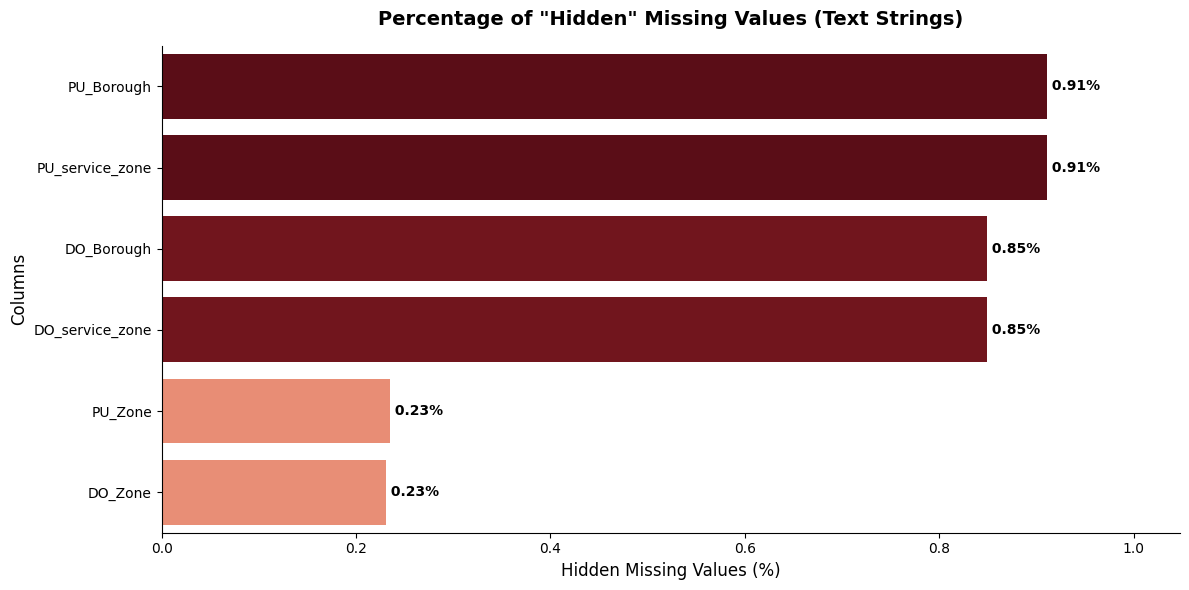

In [8]:
import matplotlib
matplotlib.use("module://ipykernel.pylab.backend_inline")

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from pyspark.sql.functions import col, sum as spark_sum, when, lower, trim

string_cols = [c for c, t in taxi_df.dtypes if t == 'string']

print("Hunting for hidden textual inconsistencies...")
hidden_nulls_exprs = [
    spark_sum(
        when(lower(trim(col(c))).isin('nan', 'null', 'n/a', 'na', '', 'unknown'), 1).otherwise(0)
    ).alias(c)
    for c in string_cols
]

hidden_missing_df = taxi_df.select(hidden_nulls_exprs)

missing_pd = hidden_missing_df.toPandas()
missing_pd_melted = missing_pd.melt(var_name='Column', value_name='Missing_Values')
missing_pd_melted = missing_pd_melted[missing_pd_melted['Missing_Values'] > 0]

if not missing_pd_melted.empty:
    TOTAL_ROWS = taxi_df.count()
    missing_pd_melted['Percentage'] = (missing_pd_melted['Missing_Values'] / TOTAL_ROWS) * 100
    missing_pd_melted = missing_pd_melted.sort_values(by='Percentage', ascending=False)

    max_pct = missing_pd_melted['Percentage'].max()
    norm = mcolors.Normalize(vmin=-max_pct * 0.3, vmax=max_pct)
    mapper = cm.ScalarMappable(norm=norm, cmap='Reds')

    missing_pd_melted['BarColor'] = [mapper.to_rgba(p) for p in missing_pd_melted['Percentage']]

    plt.figure(figsize=(12, 6))

    sns.barplot(
        data=missing_pd_melted,
        x='Percentage',
        y='Column',
        palette=list(missing_pd_melted['BarColor'])
    )

    plt.title('Percentage of "Hidden" Missing Values (Text Strings)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Hidden Missing Values (%)', fontsize=12)
    plt.ylabel('Columns', fontsize=12)

    plt.xlim(0, max_pct * 1.15)

    for index, row in enumerate(missing_pd_melted.itertuples()):
        plt.text(row.Percentage, index, f' {row.Percentage:.2f}%', va='center', fontweight='bold')

    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("Falsely missing values (like 'nan', 'null', 'n/a', etc.) were not found in string columns.")

Converting False Nulls into Missing Values

In [9]:
from pyspark.sql.functions import col, when, lower, trim, lit

bad_strings = ['nan', 'null', 'n/a', 'na', '', 'unknown']

string_cols = [c for c, t in taxi_df.dtypes if t == 'string']

for c in string_cols:
    taxi_df = taxi_df.withColumn(
        c,
        when(lower(trim(col(c))).isin(bad_strings), lit(None).cast("string"))
        .otherwise(col(c))
    )

print("Conversion completed! Verifying results...")

from pyspark.sql.functions import isnull, sum as spark_sum

print("\nNulls after cleaning text columns:")
taxi_df.select([
    spark_sum(when(isnull(col(c)), 1).otherwise(0)).alias(c)
    for c in string_cols
]).show(vertical=True)

Conversion completed! Verifying results...

Nulls after cleaning text columns:


-RECORD 0--------------------
 store_and_fwd_flag | 809967 
 PU_Borough         | 224583 
 PU_Zone            | 57887  
 PU_service_zone    | 224583 
 DO_Borough         | 209362 
 DO_Zone            | 56919  
 DO_service_zone    | 209362 



+------------+------------+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+----------+-------+---------------+----------+-------+---------------+
|DOLocationID|PULocationID|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|PU_Borough|PU_Zone|PU_service_zone|DO_Borough|DO_Zone|DO_service_zone|
+------------+------------+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+----------+-------+---------------+----------+--

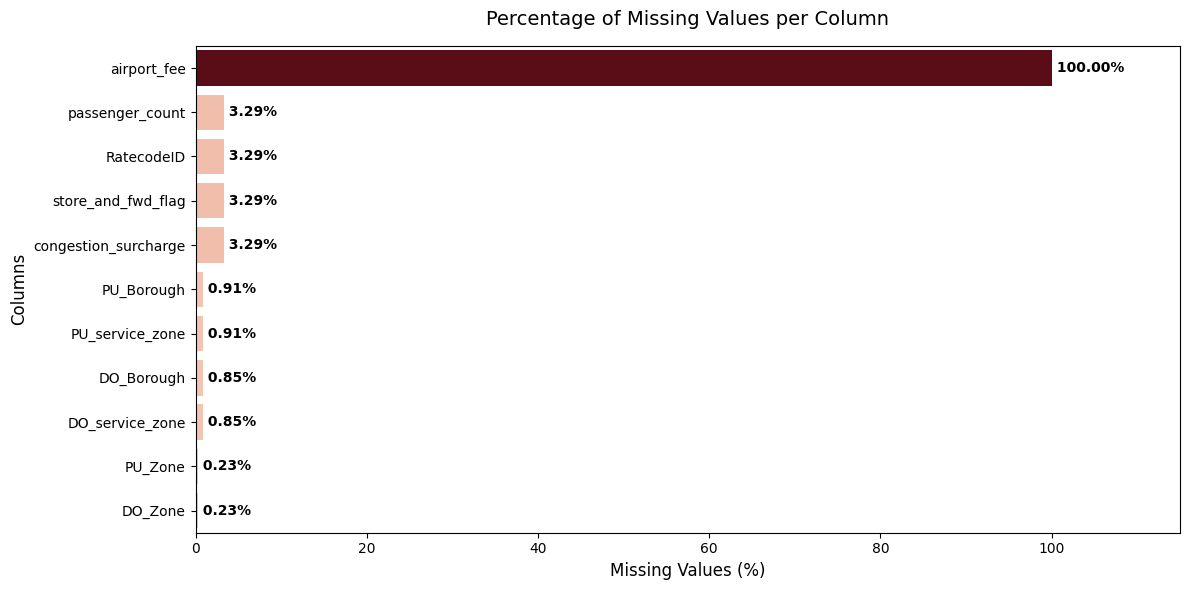

In [10]:
# 1. Prepare data
missing_df = taxi_df.select([
    _sum(col(c).isNull().cast("int")).alias(c)
    for c in taxi_df.columns
])

missing_df.show(truncate=False)

missing_pd = missing_df.toPandas()
missing_pd_melted = missing_pd.melt(var_name='Column', value_name='Missing_Values')
missing_pd_melted = missing_pd_melted[missing_pd_melted['Missing_Values'] > 0]

# 2. Calculate percentage
TOTAL_ROWS = 24649092
missing_pd_melted['Percentage'] = (missing_pd_melted['Missing_Values'] / TOTAL_ROWS) * 100
missing_pd_melted = missing_pd_melted.sort_values(by='Percentage', ascending=False)

# 3. MANUAL COLOR MAPPING (Fixed: Avoids hue_norm error)
max_pct = missing_pd_melted['Percentage'].max()
# We create a normalization object that avoids pure white (vmin)
norm = mcolors.Normalize(vmin=-max_pct * 0.3, vmax=max_pct)
mapper = cm.ScalarMappable(norm=norm, cmap='Reds')

# Assign a specific hex color to each row based on its percentage
missing_pd_melted['BarColor'] = [mapper.to_rgba(p) for p in missing_pd_melted['Percentage']]

# 4. Create the chart
plt.figure(figsize=(12, 6))

# We pass the pre-calculated colors directly to 'palette' or 'color'
sns.barplot(
    data=missing_pd_melted,
    x='Percentage',
    y='Column',
    palette=list(missing_pd_melted['BarColor'])
)

plt.title('Percentage of Missing Values per Column', fontsize=14, pad=15)
plt.xlabel('Missing Values (%)', fontsize=12)
plt.ylabel('Columns', fontsize=12)

# Extend X-axis slightly
plt.xlim(0, max_pct * 1.15)

# Add labels
for index, row in enumerate(missing_pd_melted.itertuples()):
    plt.text(row.Percentage, index, f' {row.Percentage:.2f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Outliers

Calculating statistics for the Dashboard...


Generating Master Dashboard...


26/05/12 21:54:01 WARN YarnAllocator: Container from a bad node: container_1778622189177_0001_01_000002 on host: cluster-taxi-w-1.us-east1-c.c.project-c42ab676-7327-4ef1-8b7.internal. Exit status: 143. Diagnostics: [2026-05-12 21:54:01.611]Container killed on request. Exit code is 143
[2026-05-12 21:54:01.613]Container exited with a non-zero exit code 143. 
[2026-05-12 21:54:01.614]Killed by external signal
.
26/05/12 21:54:01 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 2 for reason Container from a bad node: container_1778622189177_0001_01_000002 on host: cluster-taxi-w-1.us-east1-c.c.project-c42ab676-7327-4ef1-8b7.internal. Exit status: 143. Diagnostics: [2026-05-12 21:54:01.611]Container killed on request. Exit code is 143
[2026-05-12 21:54:01.613]Container exited with a non-zero exit code 143. 
[2026-05-12 21:54:01.614]Killed by external signal
.
26/05/12 21:54:01 ERROR YarnScheduler: Lost executor 2 on cluster-taxi-w-1.us-east1-c.c.project

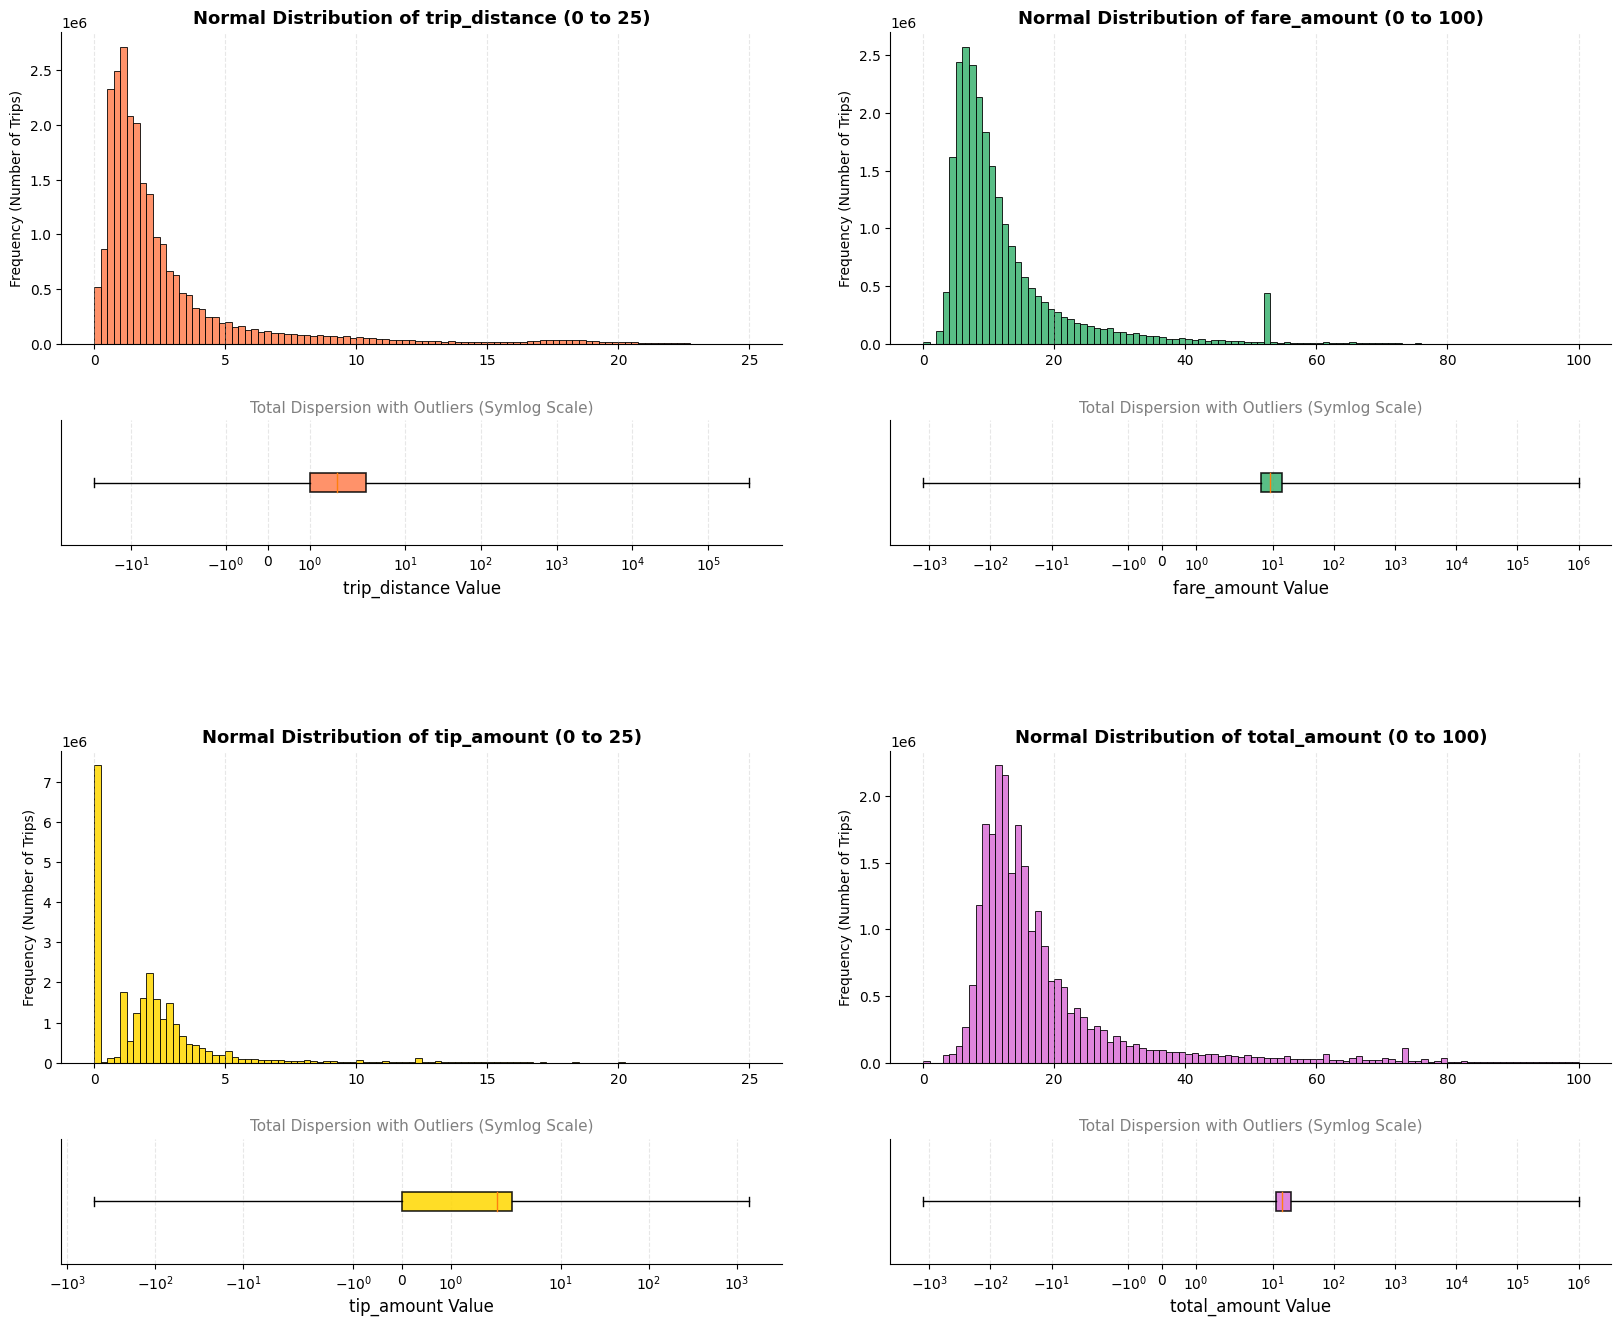

In [11]:
# 1. Function to calculate Boxplot statistics safely via Spark
def get_spark_boxplot_data(df, column):
    stats = df.select(column).dropna().approxQuantile(column, [0.0, 0.25, 0.5, 0.75, 1.0], 0.01)
    return {"min": stats[0], "q1": stats[1], "med": stats[2], "q3": stats[3], "max": stats[4]}

print("Calculating statistics for the Dashboard...")

# Define strict limits for high granularity in the core range
# Format: (Column_Name, Color, Min_Limit, Max_Limit)
cols_to_analyze = [
    ("trip_distance", "coral", 0, 25),
    ("fare_amount", "mediumseagreen", 0, 100),
    ("tip_amount", "gold", 0, 25),
    ("total_amount", "orchid", 0, 100)
]

# Store stats in a dictionary to avoid recalculating
box_data = {c_name: get_spark_boxplot_data(taxi_df, c_name) for c_name, _, _, _ in cols_to_analyze}

# =====================================================================
# MASTER DASHBOARD: HIGH GRANULARITY & OUTLINED BARS
# =====================================================================
print("Generating Master Dashboard...")

fig = plt.figure(figsize=(20, 16)) # Slightly taller to give breathing room
outer_gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.15)

for i, (column, color, min_val, max_val) in enumerate(cols_to_analyze):
    stats = box_data[column]

    # Split the areas (Ratio 2.5 to 1)
    inner_gs = gridspec.GridSpecFromSubplotSpec(
        2, 1, 
        subplot_spec=outer_gs[i], 
        height_ratios=[2.5, 1], 
        hspace=0.35 # Extra space since X-axes are now independent
    )

    # NO shared X-axis (removed sharex)
    ax_hist = fig.add_subplot(inner_gs[0])
    ax_box = fig.add_subplot(inner_gs[1])

    # --- 1. HISTOGRAM (Magnifying glass on the 'Normal' range) ---
    # Strictly filter for the normal range and increase bins to 100
    target_df = taxi_df.filter((col(column) >= min_val) & (col(column) <= max_val))
    hist_data = target_df.select(column).rdd.flatMap(lambda x: x).histogram(100)

    # Added edgecolor and linewidth for the perfect outline
    ax_hist.bar(hist_data[0][:-1], hist_data[1], width=np.diff(hist_data[0]), 
                align='edge', color=color, alpha=0.85, 
                edgecolor='black', linewidth=0.7)

    # --- 2. BOXPLOT (Global View including Outliers) ---
    ax_box.bxp([{
        'whislo': stats['min'], 'q1': stats['q1'], 'med': stats['med'], 
        'q3': stats['q3'], 'whishi': stats['max']
    }], vert=False, patch_artist=True, showfliers=False)

    # Style the Boxplot with outlines
    for patch in ax_box.patches:
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.2)

    # --- FINAL STYLING ---
    ax_hist.set_title(f'Normal Distribution of {column} ({min_val} to {max_val})', fontweight='bold', fontsize=13)
    ax_hist.set_ylabel('Frequency (Number of Trips)')

    ax_box.set_title(f'Total Dispersion with Outliers (Symlog Scale)', fontsize=11, color='gray')
    ax_box.set_xlabel(f'{column} Value', fontsize=12)

    # Only the boxplot uses the logarithmic scale to shrink the extremes
    ax_box.set_xscale('symlog')

    # Clean up design (remove top and right borders)
    for ax in [ax_hist, ax_box]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='x', alpha=0.3, linestyle='--')

    ax_box.set_yticks([]) # Remove empty Y-axis from the boxplot

plt.show()

Aggregating categorical data using Spark. Please wait...


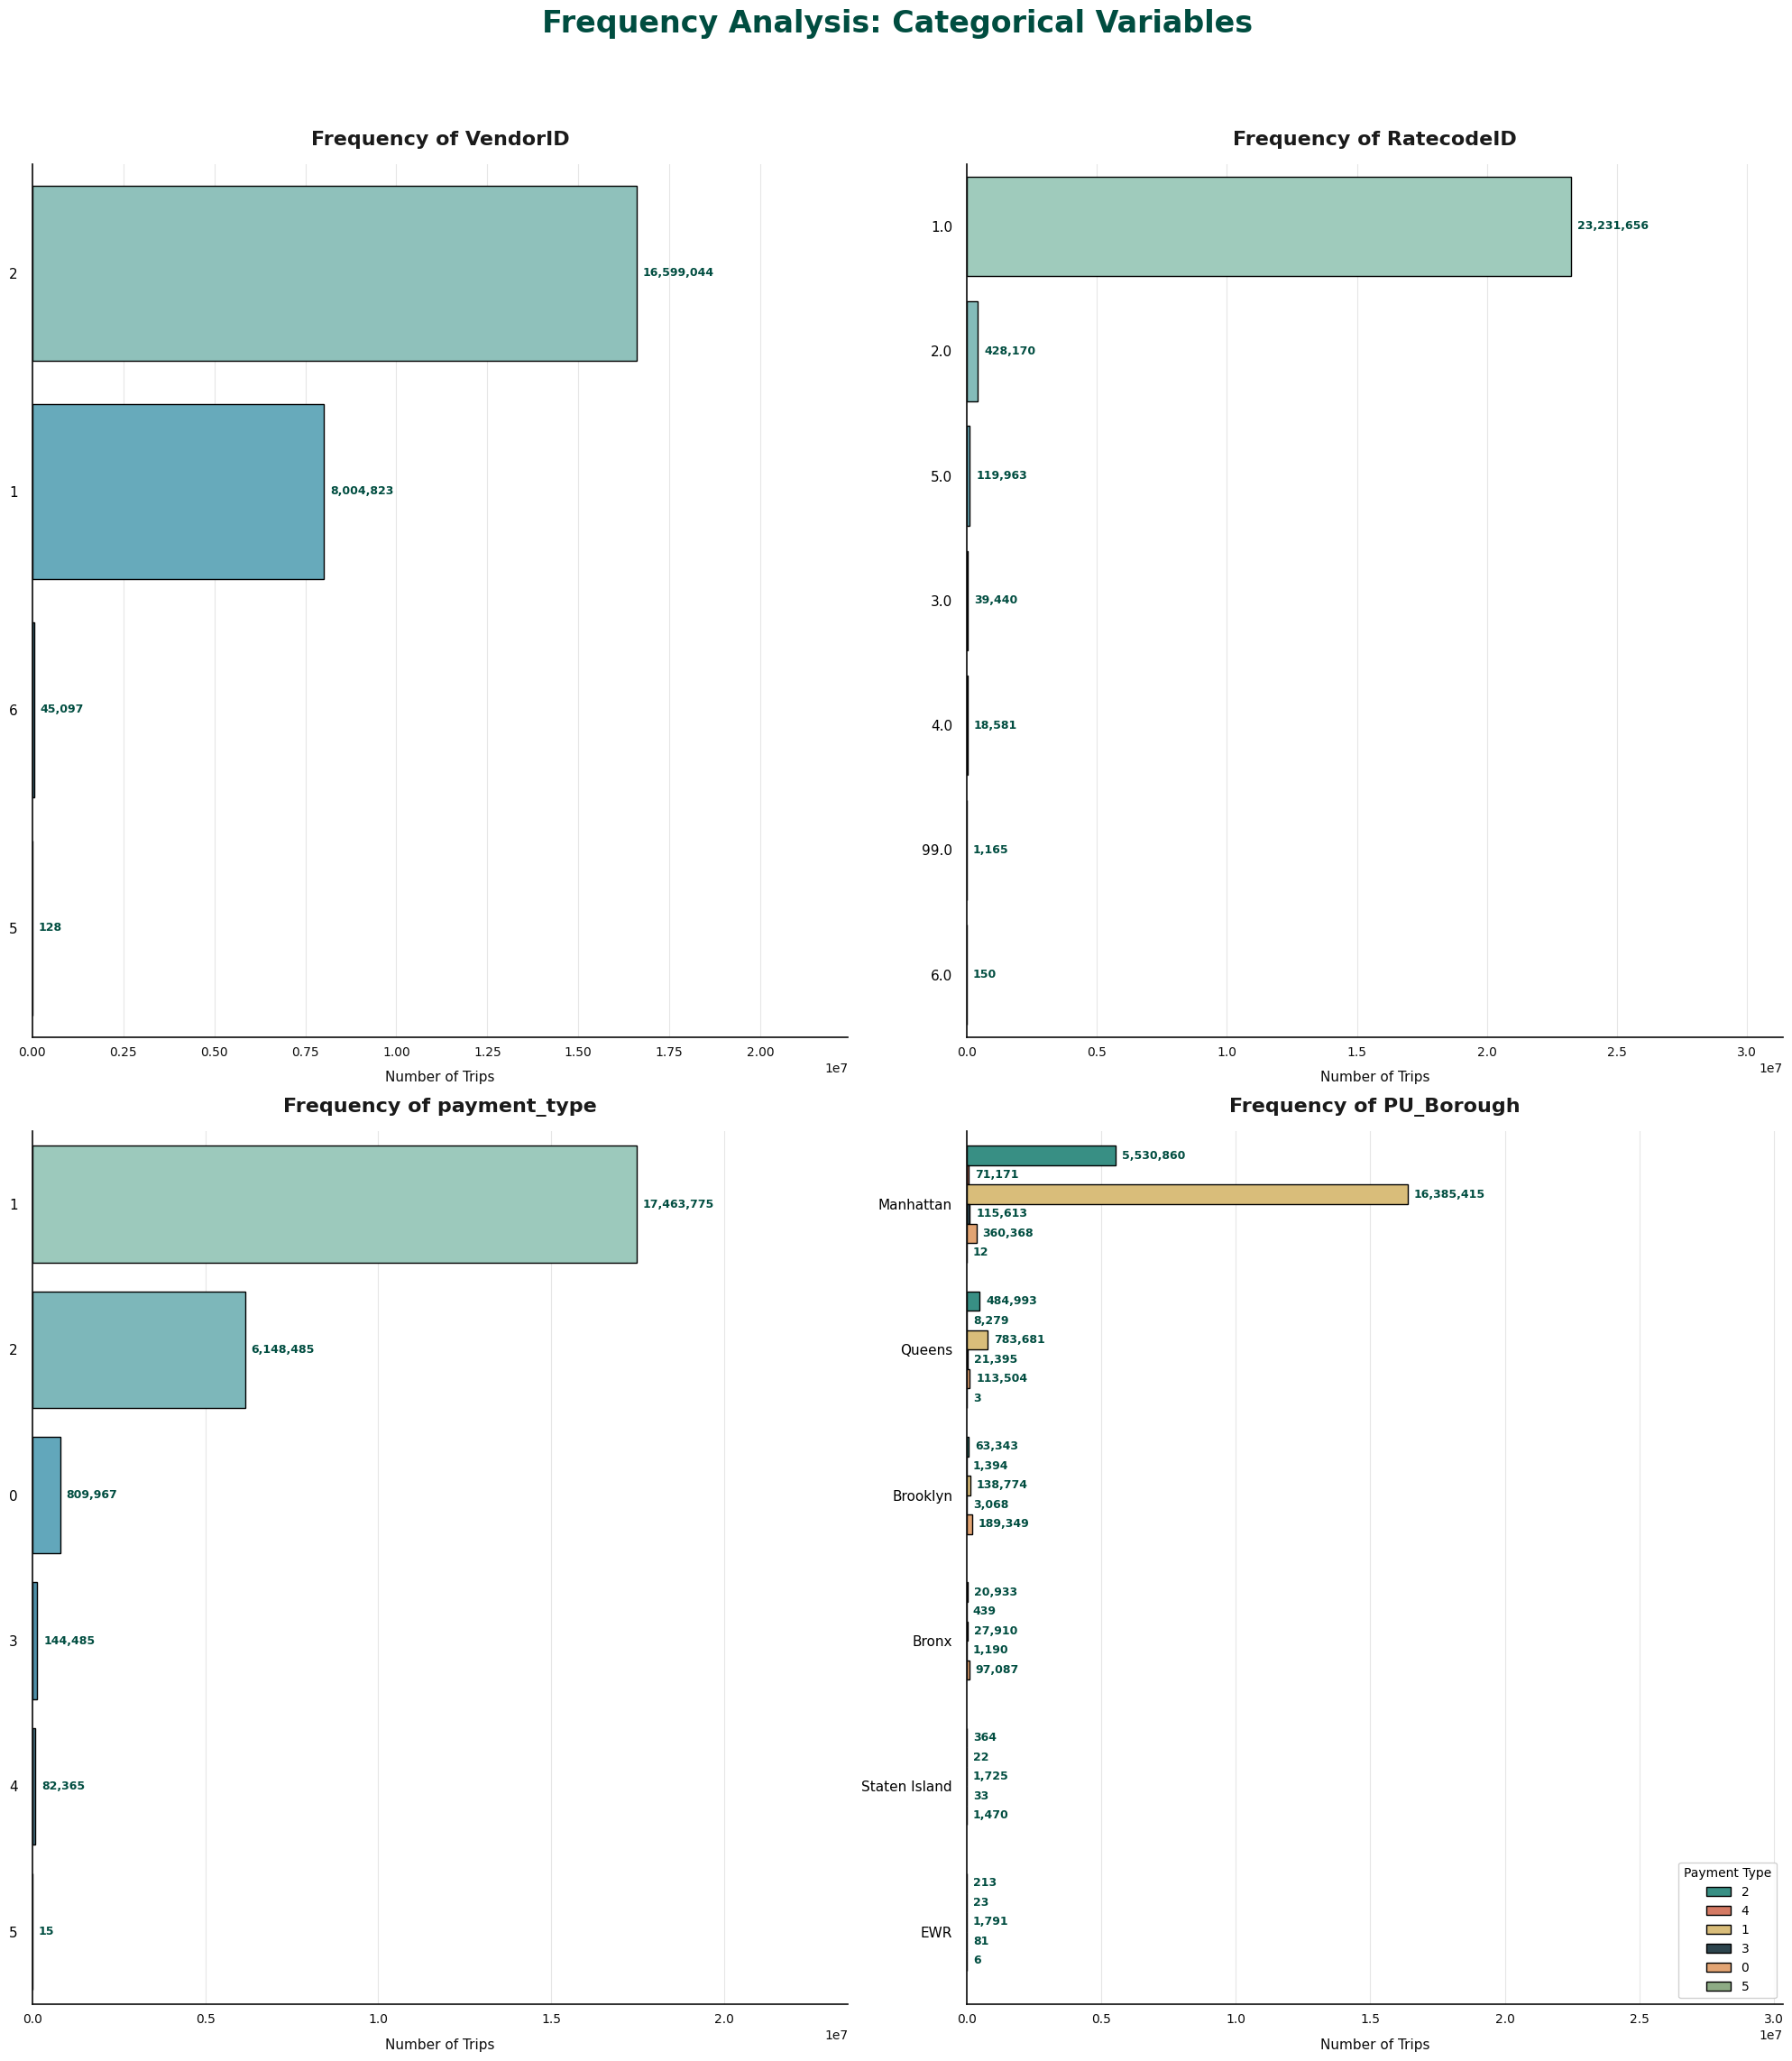

In [12]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 24))

fig.suptitle(
    'Frequency Analysis: Categorical Variables',
    fontsize=24,
    fontweight='bold',
    color='#004d40'
)

axes = axes.flatten()

cat_cols = ['VendorID', 'RatecodeID', 'payment_type', 'PU_Borough']

print("Aggregating categorical data using Spark. Please wait...")
cat_data = {}

for col_name in cat_cols:
    if col_name == 'PU_Borough':
        pdf = taxi_df.groupBy('PU_Borough', 'payment_type').count().toPandas()
        pdf['payment_type'] = pdf['payment_type'].astype(str)
    else:
        pdf = taxi_df.groupBy(col_name).count().orderBy("count", ascending=False).toPandas()

    pdf = pdf.dropna()
    pdf[col_name] = pdf[col_name].astype(str)
    cat_data[col_name] = pdf

# LOOP
for i, col_name in enumerate(cat_cols):
    ax = axes[i]
    df_plot = cat_data[col_name]

    if col_name == 'PU_Borough':
        max_val = df_plot.groupby('PU_Borough')['count'].sum().max()
    else:
        max_val = df_plot['count'].max()

    # SPECIAL CASE: PU_Borough
    if col_name == 'PU_Borough':
        order = df_plot.groupby('PU_Borough')['count'].sum().sort_values(ascending=False).index

        sns.barplot(
            data=df_plot,
            y='PU_Borough',
            x='count',
            hue='payment_type',
            order=order,
            ax=ax,
            palette=['#2a9d8f', '#e76f51', '#e9c46a', '#264653', '#f4a261', '#8ab17d'],
            edgecolor='black'
        )
        ax.legend(title='Payment Type', loc='lower right', framealpha=0.9)

    else:
        sns.barplot(
            data=df_plot,
            y=col_name,
            x='count',
            ax=ax,
            palette='GnBu_d',
            order=df_plot.sort_values('count', ascending=False)[col_name],
            edgecolor='black'
        )

    for p in ax.patches:
        width = p.get_width()

        if width > 0 and not np.isnan(width):
            ax.annotate(
                f'{int(width):,}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left',
                va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=9,
                fontweight='bold',
                color='#004d40'
            )

    # STYLE
    ax.set_title(f'Frequency of {col_name}', fontsize=16, fontweight='bold', pad=15, color='#1a1a1a')
    ax.set_xlabel('Number of Trips', fontsize=11, color='#0c0c0c', labelpad=10)
    ax.set_ylabel('')

    ax.set_axisbelow(True)
    ax.grid(axis='x', color='#e0e0e0', linestyle='-', alpha=0.8)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_color("#0c0c0c")
    ax.spines['left'].set_linewidth(1.2)

    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color("#0c0c0c")
    ax.spines['bottom'].set_linewidth(1.2)

    ax.tick_params(axis='y', which='major', left=False, pad=8, labelsize=11)

    ax.tick_params(axis='x', which='major', bottom=False, labelsize=10, colors='#0c0c0c')

    ax.set_xlim(0, max_val * 1.35)

# LAYOUT FIX
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Inconsistencies

In [13]:
# Duplicate Rows

total_rows = taxi_df.count()
unique_rows = taxi_df.distinct().count()

print(f"Total Rows: {total_rows:,}")
print(f"Duplicate Rows: {total_rows - unique_rows:,}")

# Time Anomalies

# Add duration column in minutes for analysis
taxi_df = taxi_df.withColumn("duration_min",
    (unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime")) / 60
)

# 1. Dropoff before Pickup
time_errors = taxi_df.filter(col("tpep_dropoff_datetime") <= col("tpep_pickup_datetime")).count()

# 2. Excessively long trips (e.g., > 24 hours)
long_trips = taxi_df.filter(col("duration_min") > 1440).count()

print(f"Negative/Zero Duration: {time_errors:,}")
print(f"Trips > 24h: {long_trips:,}\n")

# Distance and Speed Anomalies

# 1. Zero or negative distance
dist_errors = taxi_df.filter(col("trip_distance") <= 0).count()

# 2. Impossible speed (e.g., > 100 mph)
# Speed = Distance / (Duration in hours)
speed_outliers = taxi_df.filter(
    (col("duration_min") > 1) &
    ((col("trip_distance") / (col("duration_min") / 60)) > 100)
).count()

print(f"Zero/Negative Distance: {dist_errors:,}")
print(f"Impossible Speeds (>100mph): {speed_outliers:,}\n")

# Fare and Amount Anomalies

# 1. Negative fares
fare_errors = taxi_df.filter(col("fare_amount") < 0).count()

# 2. Incorrect sum (Check if Total = Sum of all components)
# Using spark_abs (PySpark's abs) instead of native Python abs
sum_mismatch = taxi_df.filter(
    spark_abs(col("total_amount") - (
        col("fare_amount") + col("extra") + col("mta_tax") + 
        col("tip_amount") + col("tolls_amount") + col("improvement_surcharge") + 
        col("congestion_surcharge") + col("airport_fee")
    )) > 0.1
).count()

print(f"Negative Fare Amounts: {fare_errors:,}")
print(f"Total Amount Mismatches: {sum_mismatch:,}\n")

# Passenger Count and Ratecode Anomalies

# 1. Zero or negative passengers
pass_errors = taxi_df.filter((col("passenger_count") <= 0) | (col("passenger_count") > 9)).count()

# 2. Invalid RatecodeID (NYC defines only 1 to 6)
rate_errors = taxi_df.filter(~col("RatecodeID").isin([1, 2, 3, 4, 5, 6])).count()

print(f"Passenger Count Errors: {pass_errors:,}")
print(f"Invalid RateCodes: {rate_errors:,}\n")

# Summary of Inconsistencies
results = [
    ("Duplicate Rows", total_rows - unique_rows),
    ("Negative Duration", time_errors),
    ("Zero/Negative Distance", dist_errors),
    ("Negative Fares", fare_errors),
    ("Invalid Passenger Count", pass_errors),
    ("Invalid RateCodes", rate_errors)
]

print("\nSummary of Data Inconsistencies:")
print(f"{'Inconsistency Type':<30} | {'Count':<15}")
print("-" * 50)
for label, value in results:
    print(f"{label:<30} | {value:<15,}")

26/05/12 21:56:12 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/05/12 21:56:21 WARN YarnAllocator: Container from a bad node: container_1778622189177_0001_01_000001 on host: cluster-taxi-w-0.us-east1-c.c.project-c42ab676-7327-4ef1-8b7.internal. Exit status: 143. Diagnostics: [2026-05-12 21:56:20.900]Container killed on request. Exit code is 143
[2026-05-12 21:56:20.903]Container exited with a non-zero exit code 143. 
[2026-05-12 21:56:20.904]Killed by external signal
.
26/05/12 21:56:21 ERROR YarnScheduler: Lost executor 1 on cluster-taxi-w-0.us-east1-c.c.project-c42ab676-7327-4ef1-8b7.internal: Container from a bad node: container_1778622189177_0001_01_000001 on host: cluster-taxi-w-0.us-east1-c.c.project-c42ab676-7327-4ef1-8b7.internal. Exit status: 143. Diagnostics: [2026-05-12 21:56:20.900]Container killed on request. Exit code is 143
[2026-05-12 21:56:20.903]Conta

Total Rows: 24,649,092
Duplicate Rows: 12,950


Negative/Zero Duration: 37,412
Trips > 24h: 55



Zero/Negative Distance: 332,448
Impossible Speeds (>100mph): 1,306



Negative Fare Amounts: 92,833
Total Amount Mismatches: 14



Passenger Count Errors: 489,385
Invalid RateCodes: 1,165


Summary of Data Inconsistencies:
Inconsistency Type             | Count          
--------------------------------------------------
Duplicate Rows                 | 12,950         
Negative Duration              | 37,412         
Zero/Negative Distance         | 332,448        
Negative Fares                 | 92,833         
Invalid Passenger Count        | 489,385        
Invalid RateCodes              | 1,165          


## **Data Cleaning**

### Cleaning Missing Values

In [14]:
print("Starting Data Cleaning Pipeline...")

# 100% Missing
taxi_df = taxi_df.drop("airport_fee")

# ~3.29% Missing
taxi_df = taxi_df \
    .withColumn(
        "RatecodeID",
        when(col("RatecodeID").isNull(),
             # If origin or destination is JFK (Zone ID 132 is JFK), apply RateCode 2
             when((col("PULocationID") == 132) | (col("DOLocationID") == 132), 2.0)
             # Otherwise, apply the standard fare (1)
             .otherwise(1.0)
        ).otherwise(col("RatecodeID"))
    ) \
    .withColumn(
        "congestion_surcharge",
        when(col("congestion_surcharge").isNull(),
             # If started or ended in Manhattan, apply the $2.50 fee
             when((col("PU_Borough") == 'Manhattan') | (col("DO_Borough") == 'Manhattan'), 2.5)
             .otherwise(0.0)
        ).otherwise(col("congestion_surcharge"))
    ) \
    .fillna({
        "passenger_count": 1.0,
        "store_and_fwd_flag": "N"
    })

# < 1% Missing
# Drop rows where critical geographic or categorical data is still missing
geo_cols_to_check = [
    "PU_Borough", "PU_service_zone", "PU_Zone",
    "DO_Borough", "DO_service_zone", "DO_Zone"
]

taxi_df = taxi_df.dropna(subset=geo_cols_to_check)

print("Data Cleaning and Imputation completed!")

# Validation
check_cols = [
    "passenger_count", "RatecodeID", "store_and_fwd_flag",
    "congestion_surcharge", "PU_Borough", "DO_Borough"
]

print("\nFinal Null Count Check (Should be all 0):")
taxi_df.select([
    _sum(col(c).isNull().cast("int")).alias(c)
    for c in check_cols
]).show(vertical=True)


Starting Data Cleaning Pipeline...
Data Cleaning and Imputation completed!

Final Null Count Check (Should be all 0):


-RECORD 0-------------------
 passenger_count      | 0   
 RatecodeID           | 0   
 store_and_fwd_flag   | 0   
 congestion_surcharge | 0   
 PU_Borough           | 0   
 DO_Borough           | 0   



### Cleaning Inconsistencies

In [15]:
# 1. Deduplication
taxi_df = taxi_df.dropDuplicates()

# 2. Add temporary duration for filtering
taxi_df = taxi_df.withColumn("duration_h",
    (unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime")) / 3600
)

# 3. Apply all Business Rules
taxi_df = taxi_df.filter(
    (col("duration_h") > 0) & (col("duration_h") < 24) &             # Logical time
    (col("trip_distance") > 0) & (col("trip_distance") < 500) &      # Physical distance
    (col("fare_amount") > 0) & (col("total_amount") > 0) &           # Financial logic
    (col("passenger_count") > 0) & (col("passenger_count") < 10) &   # Reality check
    (col("RatecodeID").isin([1, 2, 3, 4, 5, 6]))                     # Official codes
)

# 4. Remove speed outliers (Average speed < 100 mph)
taxi_df = taxi_df.filter((col("trip_distance") / col("duration_h")) < 100)

# 5. Drop the temporary column
taxi_df = taxi_df.drop("duration_h")
new_count = taxi_df.count()

# Final check
print(f"Original rows: {total_rows:,}")
print(f"Cleaned rows: {new_count:,}")
print(f"Data loss: {((total_rows - new_count) / total_rows) * 100:.2f}%")

Original rows: 24,649,092


Cleaned rows: 23,460,332


Data loss: 4.82%


### Feature Engineering

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pyspark.sql.functions import hour, dayofweek, month, col, avg, when, unix_timestamp, floor, count as spark_count

print("Feature Engineering...")

taxi_df = taxi_df.filter(
    (col("trip_distance") > 0) &
    (col("fare_amount") > 0) &
    (col("tpep_dropoff_datetime") > col("tpep_pickup_datetime"))
)

taxi_df = taxi_df.withColumn("hour", hour("tpep_pickup_datetime")) \
    .withColumn("day_of_week", dayofweek("tpep_pickup_datetime")) \
    .withColumn("month", month("tpep_pickup_datetime")) \
    .withColumn("duration_m", (unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime")) / 60) \
    .withColumn("speed_mph", col("trip_distance") / (col("duration_m") / 60)) \
    .withColumn("tip_pct", when(col("payment_type") == 1, (col("tip_amount") / col("fare_amount")) * 100).otherwise(0)) \
    .withColumn("payment_name", when(col("payment_type") == 1, "Credit Card").when(col("payment_type") == 2, "Cash").otherwise("Other")) \
    .withColumn("VendorName", when(col("VendorID") == 1, "Creative Mobile").when(col("VendorID") == 2, "VeriFone").otherwise("Outros")) \
    .withColumn("RateName",
        when(col("RatecodeID") == 1, "Standard")
        .when(col("RatecodeID") == 2, "JFK")
        .when(col("RatecodeID") == 3, "Newark")
        .when(col("RatecodeID") == 4, "Nassau")
        .when(col("RatecodeID") == 5, "Negotiated")
        .otherwise("Group Ride")
    )

print("Features engineered successfully!")

Feature Engineering...
Features engineered successfully!


### Data Exploration

Temporal Analysis

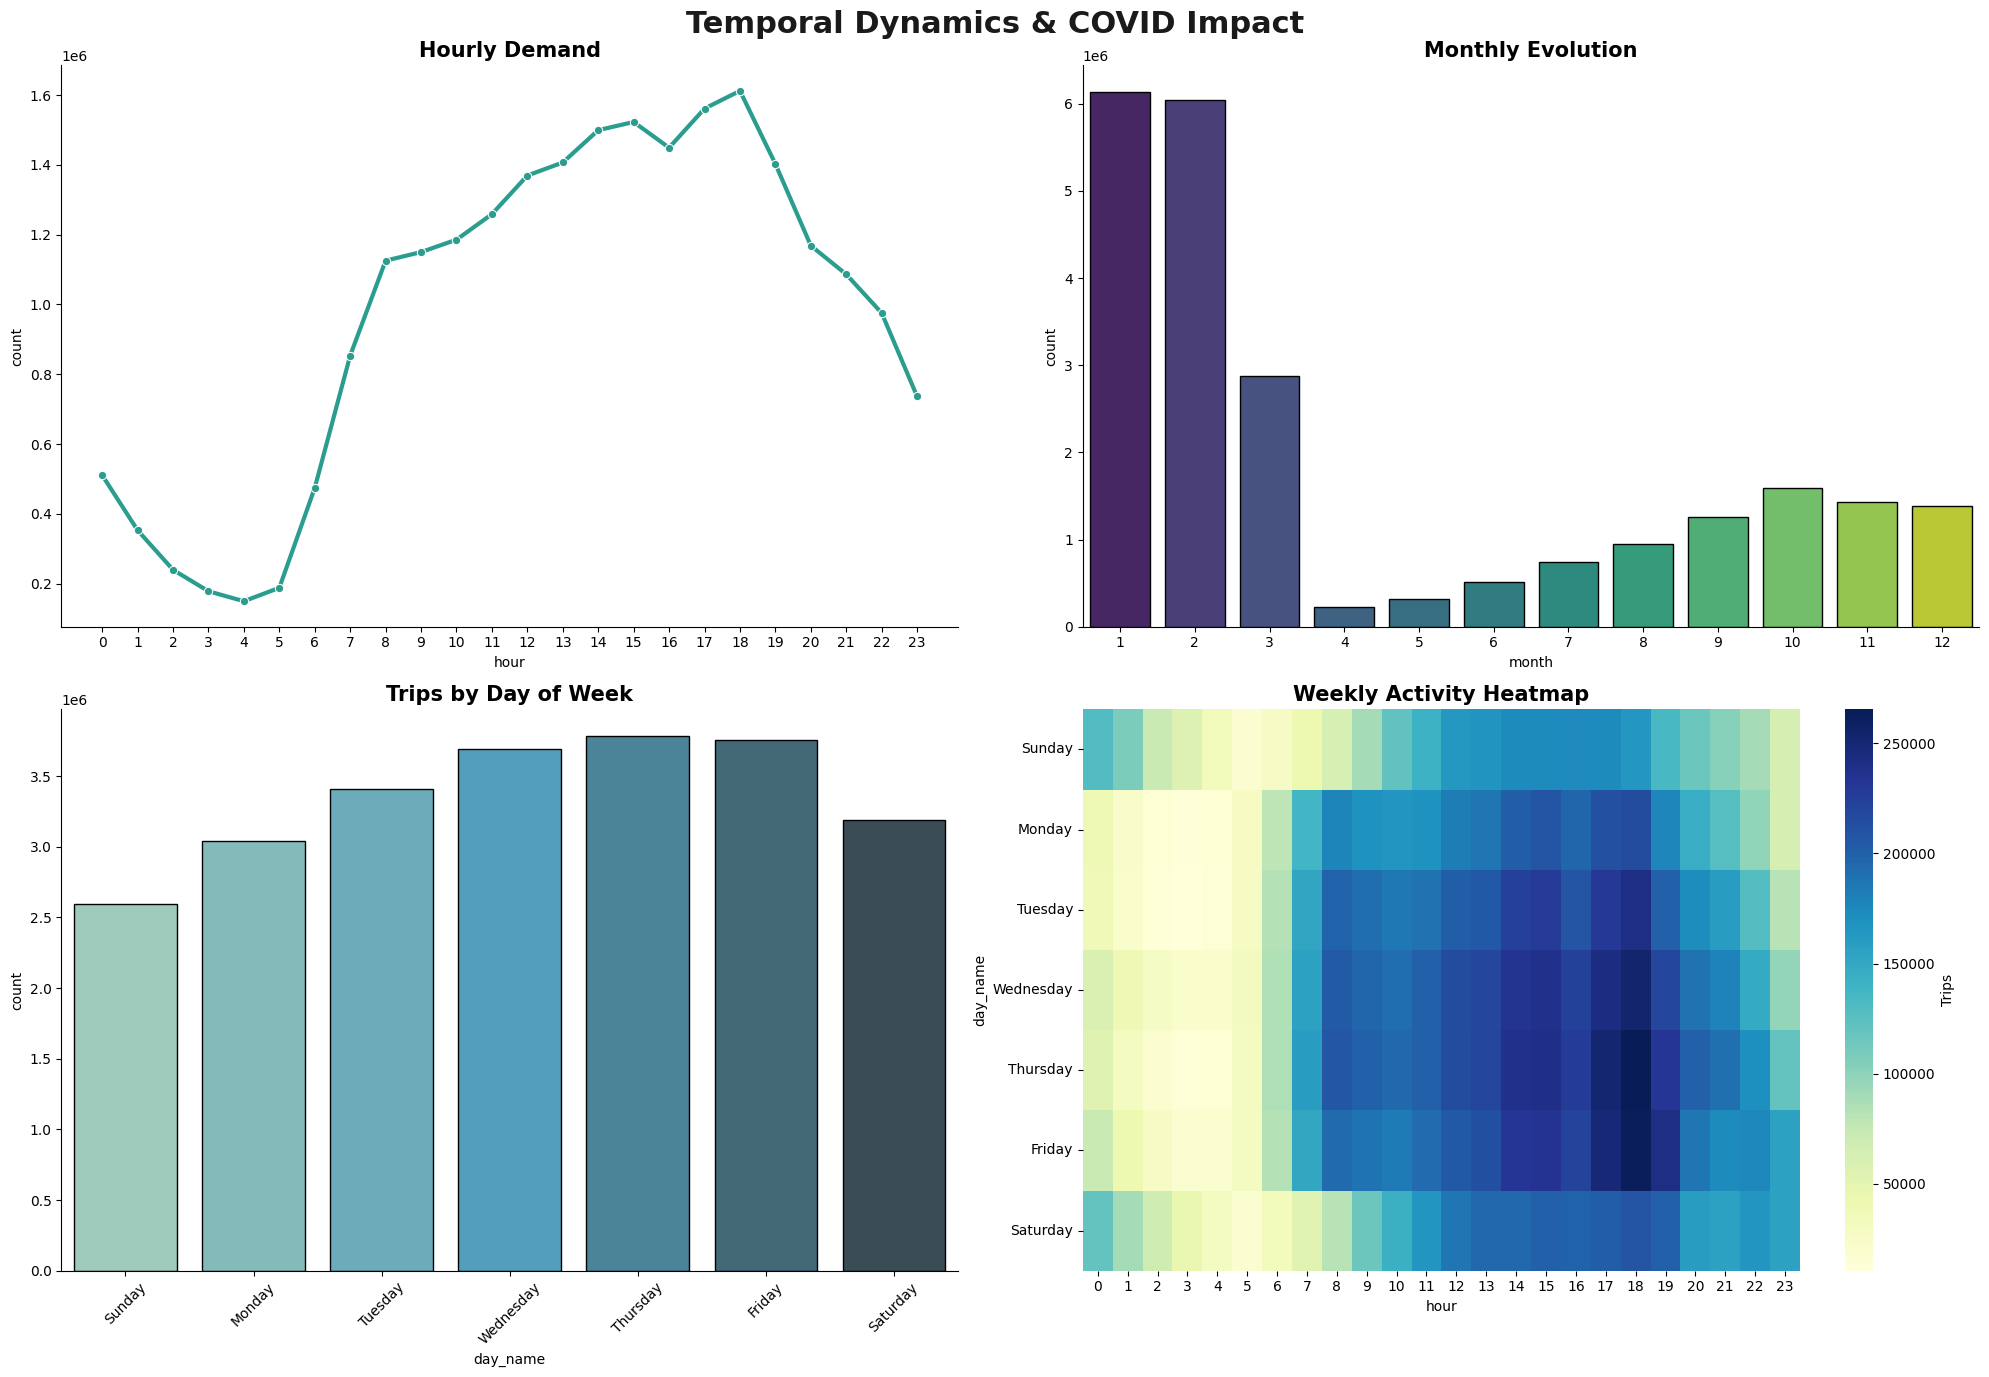

In [17]:
day_labels = {
    1: "Sunday",
    2: "Monday",
    3: "Tuesday",
    4: "Wednesday",
    5: "Thursday",
    6: "Friday",
    7: "Saturday"
}

hourly_data = taxi_df.groupBy("hour").count().orderBy("hour").toPandas()
monthly_data = taxi_df.groupBy("month").count().orderBy("month").toPandas()

weekday_data = (
    taxi_df.groupBy("day_of_week")
    .count()
    .orderBy("day_of_week")
    .toPandas()
)
weekday_data["day_name"] = weekday_data["day_of_week"].map(day_labels)

heatmap_df = taxi_df.groupBy("day_of_week", "hour").count().toPandas()
heatmap_df["day_name"] = heatmap_df["day_of_week"].map(day_labels)

day_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
heatmap_pivot = (
    heatmap_df.pivot(index="day_name", columns="hour", values="count")
    .reindex(day_order)
)

fig, ax = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('Temporal Dynamics & COVID Impact', fontsize=22, fontweight='bold', color='#1a1a1a')

sns.lineplot(data=hourly_data, x="hour", y="count", marker="o", linewidth=3, color="#2a9d8f", ax=ax[0,0])
ax[0,0].set_title("Hourly Demand", fontsize=15, fontweight='bold')
ax[0,0].set_xticks(range(0, 24))

sns.barplot(data=monthly_data, x="month", y="count", palette="viridis", edgecolor="black", ax=ax[0,1])
ax[0,1].set_title("Monthly Evolution", fontsize=15, fontweight='bold')

sns.barplot(data=weekday_data, x="day_name", y="count", palette="GnBu_d", edgecolor="black", ax=ax[1,0])
ax[1,0].set_title("Trips by Day of Week", fontsize=15, fontweight='bold')
ax[1,0].tick_params(axis='x', rotation=45)

sns.heatmap(heatmap_pivot, cmap="YlGnBu", ax=ax[1,1], cbar_kws={'label': 'Trips'})
ax[1,1].set_title("Weekly Activity Heatmap", fontsize=15, fontweight='bold')

for axes in [ax[0,0], ax[0,1], ax[1,0]]:
    axes.spines['top'].set_visible(False)
    axes.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

NYC Traffic Dynamics & Trip Distributions

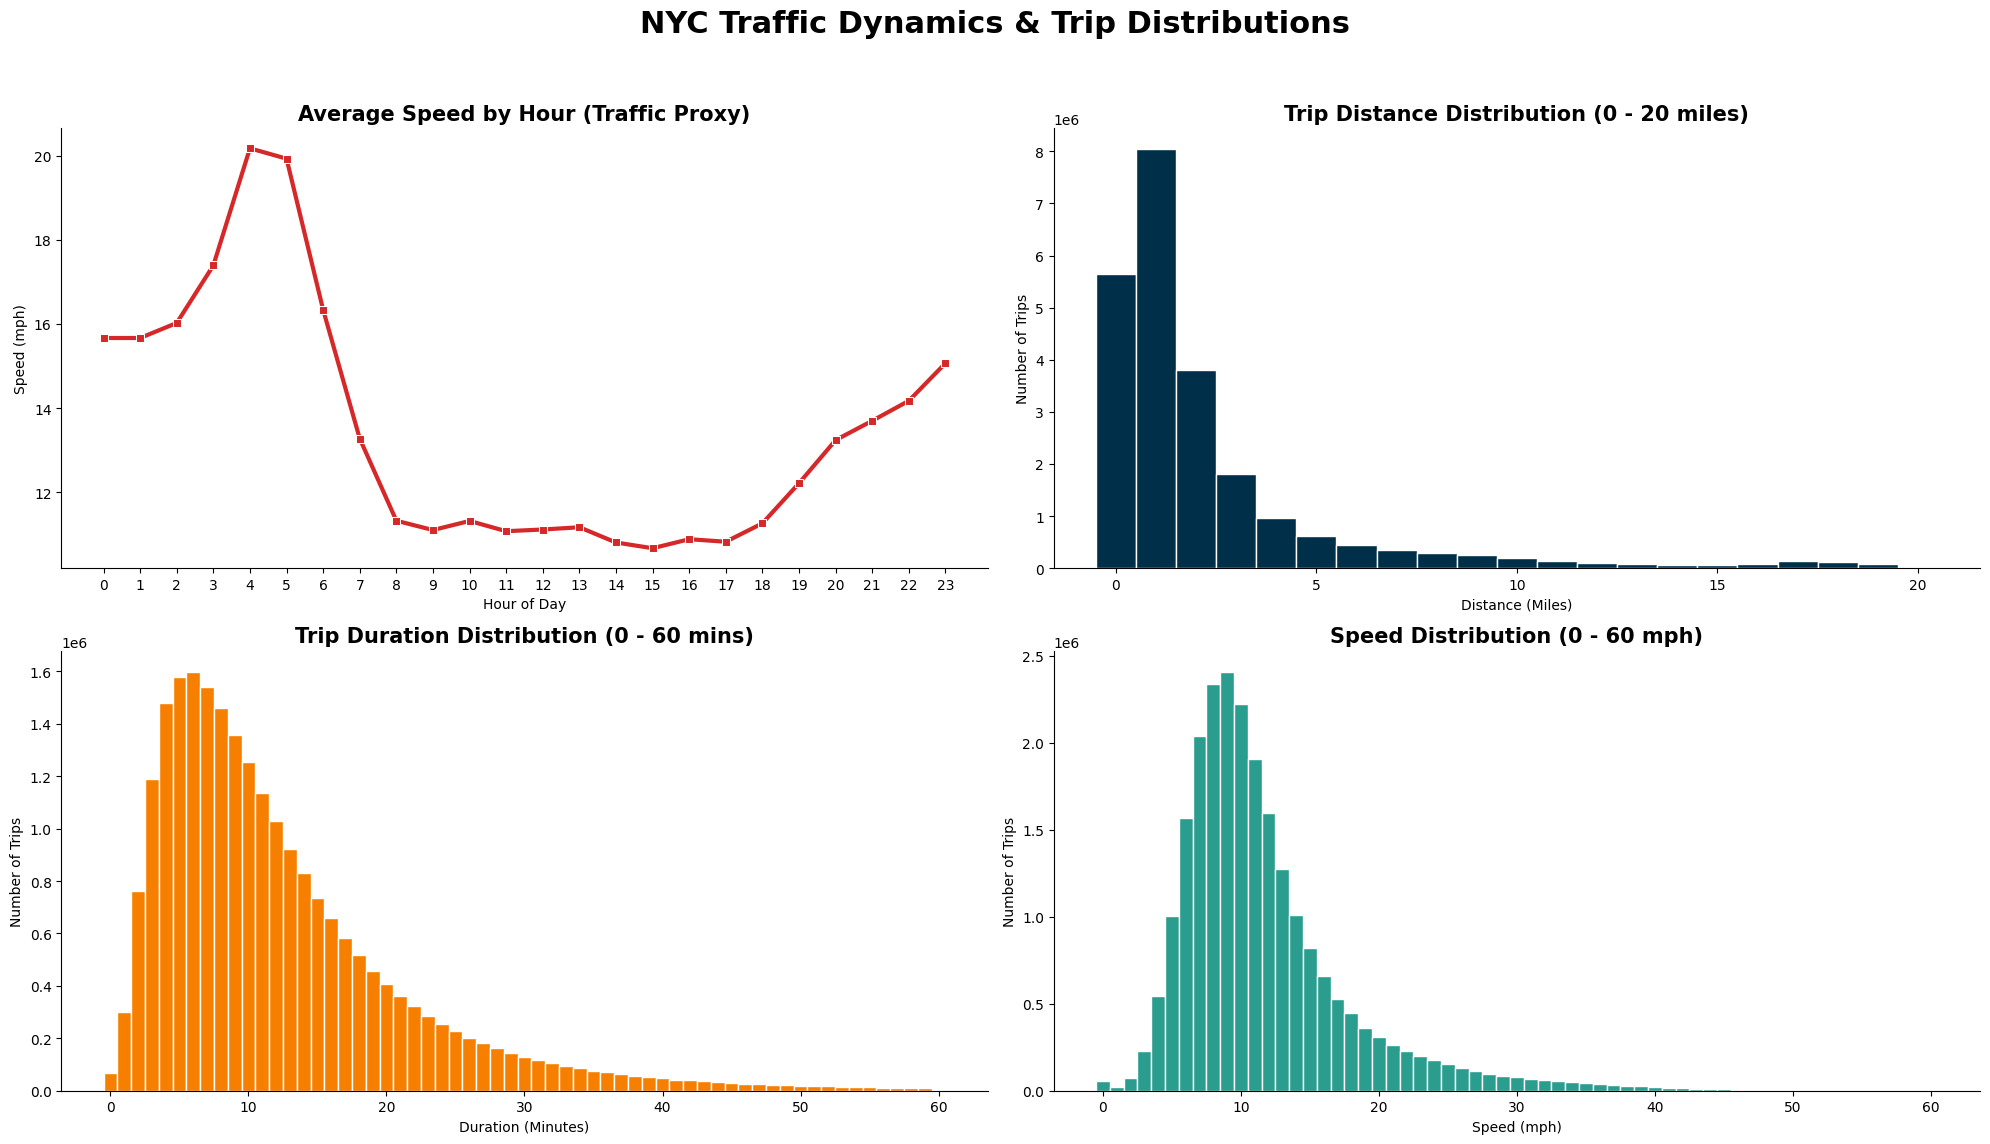

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql.functions import hour, avg, col, unix_timestamp, floor, when

# 1. FEATURE ENGINEERING
taxi_df_physics = taxi_df.withColumn(
    "duration_m", (unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime")) / 60
).withColumn(
    "hour", hour("tpep_pickup_datetime")
)

# Filter out unrealistic trips before calculating speed
taxi_df_physics = taxi_df_physics.filter((col("duration_m") > 0) & (col("trip_distance") > 0)) \
    .withColumn("speed_mph", col("trip_distance") / (col("duration_m") / 60))


# 2. Aggregations
speed_hour = taxi_df_physics.filter(col("speed_mph") < 80) \
    .groupBy("hour").agg(avg("speed_mph").alias("avg_speed")).orderBy("hour").toPandas()

dist_bins = taxi_df_physics.filter(col("trip_distance") <= 20) \
    .withColumn("dist_bin", floor(col("trip_distance"))) \
    .groupBy("dist_bin").count().orderBy("dist_bin").toPandas()

dur_bins = taxi_df_physics.filter(col("duration_m") <= 60) \
    .withColumn("dur_bin", floor(col("duration_m"))) \
    .groupBy("dur_bin").count().orderBy("dur_bin").toPandas()

speed_bins = taxi_df_physics.filter((col("speed_mph") >= 0) & (col("speed_mph") <= 60)) \
    .withColumn("speed_bin", floor(col("speed_mph"))) \
    .groupBy("speed_bin").count().orderBy("speed_bin").toPandas()


# 3. PLOTS
fig, ax = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('NYC Traffic Dynamics & Trip Distributions', fontsize=22, fontweight='bold')

# Top Left: Velocidade Média por Hora (Trânsito)
sns.lineplot(data=speed_hour, x="hour", y="avg_speed", marker="s", color="#d62828", linewidth=3, ax=ax[0,0])
ax[0,0].set_title("Average Speed by Hour (Traffic Proxy)", fontsize=15, fontweight='bold')
ax[0,0].set_xlabel("Hour of Day")
ax[0,0].set_ylabel("Speed (mph)")
ax[0,0].set_xticks(range(0, 24))

# Top Right: Trip Distance Distribution
ax[0,1].bar(dist_bins['dist_bin'], dist_bins['count'], color="#003049", edgecolor='white', width=1.0)
ax[0,1].set_title("Trip Distance Distribution (0 - 20 miles)", fontsize=15, fontweight='bold')
ax[0,1].set_xlabel("Distance (Miles)")
ax[0,1].set_ylabel("Number of Trips")

# Bottom Left: Trip Duration Distribution
ax[1,0].bar(dur_bins['dur_bin'], dur_bins['count'], color="#f77f00", edgecolor='white', width=1.0)
ax[1,0].set_title("Trip Duration Distribution (0 - 60 mins)", fontsize=15, fontweight='bold')
ax[1,0].set_xlabel("Duration (Minutes)")
ax[1,0].set_ylabel("Number of Trips")

# Bottom Right: Speed Distribution (O NOVO GRÁFICO)
ax[1,1].bar(speed_bins['speed_bin'], speed_bins['count'], color="#2a9d8f", edgecolor='white', width=1.0)
ax[1,1].set_title("Speed Distribution (0 - 60 mph)", fontsize=15, fontweight='bold')
ax[1,1].set_xlabel("Speed (mph)")
ax[1,1].set_ylabel("Number of Trips")

# Limpeza estética
for axes in [ax[0,0], ax[0,1], ax[1,0], ax[1,1]]:
    axes.spines['top'].set_visible(False)
    axes.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Spatial Dynamics & Real Tip Quality

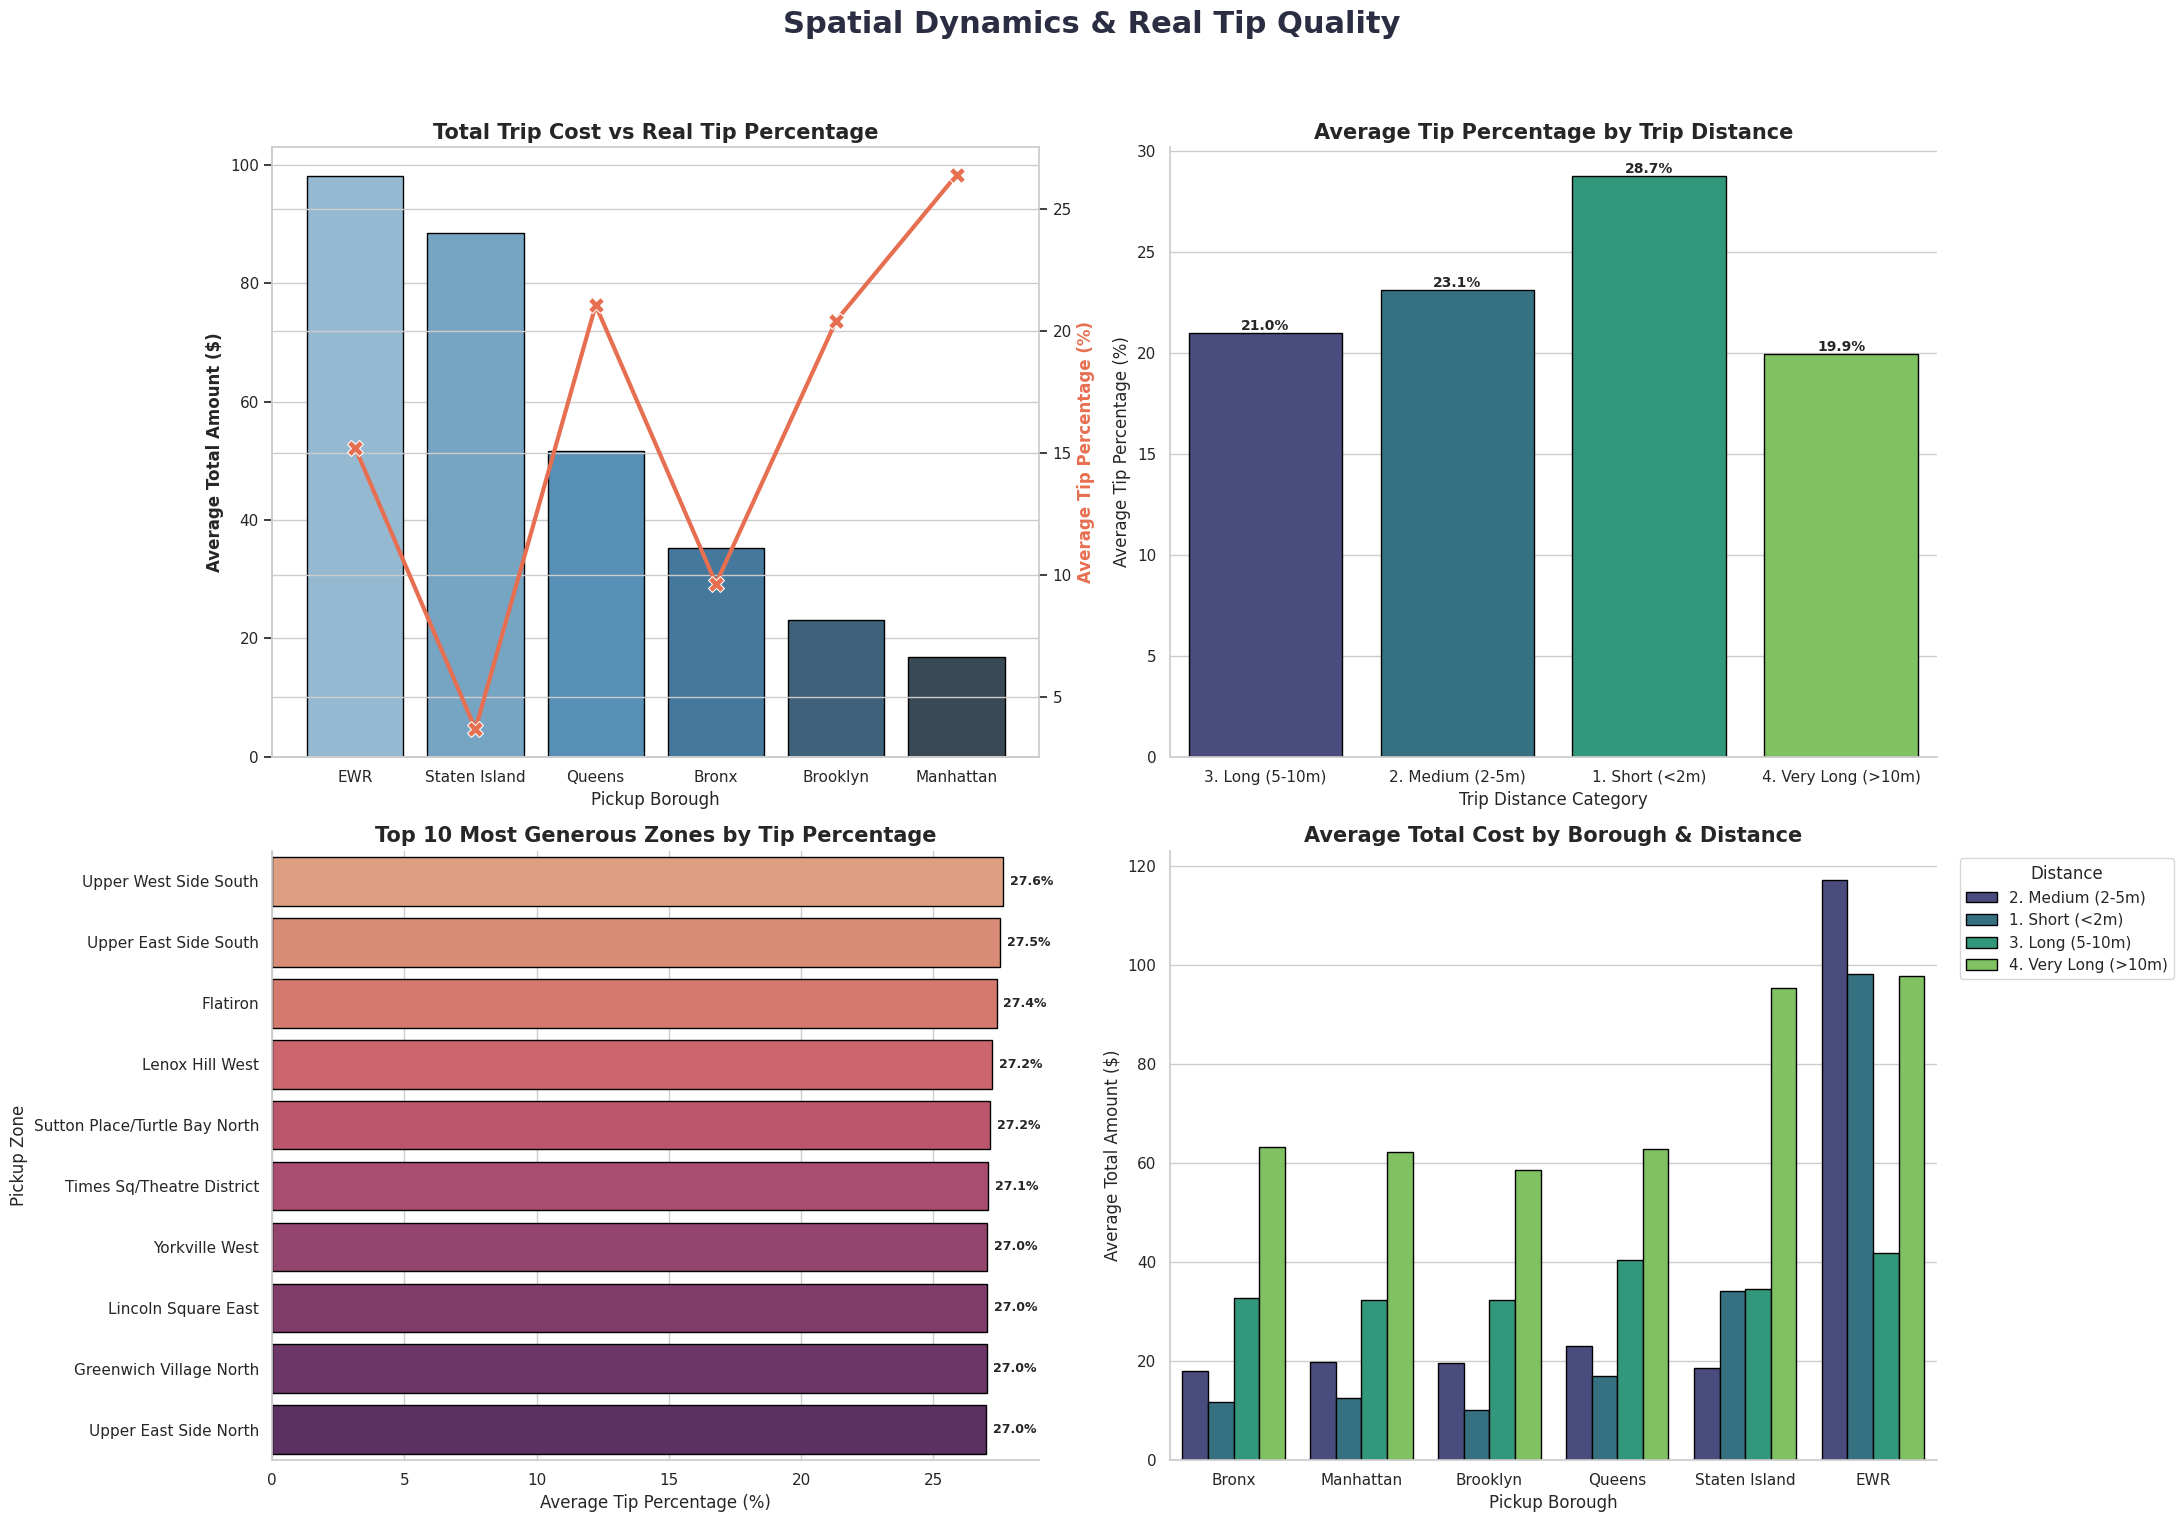

In [19]:
from pyspark.sql.functions import count as spark_count, col, avg, when

import matplotlib.pyplot as plt
import seaborn as sns

# 1. FEATURE ENGINEERING

taxi_df_geo = taxi_df.filter(
    (col("payment_type") == 1) & (col("fare_amount") > 0)
).withColumn(
    "tip_pct",
    (col("tip_amount") / col("fare_amount")) * 100
).filter(
    col("tip_pct") <= 100
).withColumn(
    "distance_category",
    when(col("trip_distance") < 2, "1. Short (<2m)")
    .when(
        (col("trip_distance") >= 2) & (col("trip_distance") < 5),
        "2. Medium (2-5m)"
    )
    .when(
        (col("trip_distance") >= 5) & (col("trip_distance") < 10),
        "3. Long (5-10m)"
    )
    .otherwise("4. Very Long (>10m)")
)

# 2. Aggregations

# 1. Borough Cost vs Tip Percentage
cost_tip_borough = taxi_df_geo.groupBy("PU_Borough") \
    .agg(
        avg("total_amount").alias("avg_total"),
        avg("tip_pct").alias("avg_tip_pct")
    ) \
    .orderBy("avg_total", ascending=False) \
    .toPandas()

# 2. Tip Percentage vs Distance Category
tip_distance = taxi_df_geo.groupBy("distance_category") \
    .agg(
        avg("tip_pct").alias("avg_tip_pct"),
        avg("total_amount").alias("avg_total")
    ) \
    .toPandas()

# 3. Top Generous Zones
top_tip_zones = taxi_df_geo.groupBy("PU_Zone") \
    .agg(
        avg("tip_pct").alias("avg_tip_pct"),
        spark_count("*").alias("trips")
    ) \
    .filter(col("trips") > 1000) \
    .orderBy("avg_tip_pct", ascending=False) \
    .limit(10) \
    .toPandas()

# 4. Average Cost by Borough and Distance
dist_cost_cat = taxi_df_geo.groupBy(
    "PU_Borough",
    "distance_category"
).agg(
    avg("total_amount").alias("avg_total")
).toPandas()

# 3. Plots
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(2, 2, figsize=(22, 16))

fig.suptitle(
    'Spatial Dynamics & Real Tip Quality',
    fontsize=22,
    fontweight='bold',
    color='#2b2d42'
)

# TOP LEFT: Total Cost vs Tip Percentage
sns.barplot(
    data=cost_tip_borough,
    x="PU_Borough",
    y="avg_total",
    palette="Blues_d",
    edgecolor="black",
    ax=ax[0, 0]
)

ax[0, 0].set_ylabel(
    "Average Total Amount ($)",
    fontsize=12,
    fontweight='bold'
)

ax[0, 0].set_xlabel(
    "Pickup Borough",
    fontsize=12
)

ax[0, 0].set_title(
    "Total Trip Cost vs Real Tip Percentage",
    fontsize=15,
    fontweight='bold'
)

ax2_geo = ax[0, 0].twinx()

sns.lineplot(
    data=cost_tip_borough,
    x=ax[0, 0].get_xticks(),
    y="avg_tip_pct",
    marker="X",
    color="#e76f51",
    markersize=12,
    linewidth=3,
    ax=ax2_geo
)

ax2_geo.set_ylabel(
    "Average Tip Percentage (%)",
    fontsize=12,
    fontweight='bold',
    color="#e76f51"
)

# TOP RIGHT: Tip Percentage vs Distance
sns.barplot(
    data=tip_distance,
    x="distance_category",
    y="avg_tip_pct",
    palette="viridis",
    edgecolor="black",
    ax=ax[0, 1]
)

ax[0, 1].set_title(
    "Average Tip Percentage by Trip Distance",
    fontsize=15,
    fontweight='bold'
)

ax[0, 1].set_xlabel(
    "Trip Distance Category",
    fontsize=12
)

ax[0, 1].set_ylabel(
    "Average Tip Percentage (%)",
    fontsize=12
)

for p in ax[0, 1].patches:

    height = p.get_height()

    ax[0, 1].annotate(
        f'{height:.1f}%',
        (
            p.get_x() + p.get_width() / 2.,
            height
        ),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# BOTTOM LEFT: Most Generous Zones
sns.barplot(
    data=top_tip_zones,
    x="avg_tip_pct",
    y="PU_Zone",
    palette="flare",
    edgecolor="black",
    ax=ax[1, 0]
)

ax[1, 0].set_title(
    "Top 10 Most Generous Zones by Tip Percentage",
    fontsize=15,
    fontweight='bold'
)

ax[1, 0].set_xlabel(
    "Average Tip Percentage (%)",
    fontsize=12
)

ax[1, 0].set_ylabel(
    "Pickup Zone",
    fontsize=12
)

for p in ax[1, 0].patches:

    width = p.get_width()

    ax[1, 0].annotate(
        f'{width:.1f}%',
        (
            width,
            p.get_y() + p.get_height() / 2
        ),
        ha='left',
        va='center',
        fontsize=9,
        fontweight='bold',
        xytext=(5, 0),
        textcoords='offset points'
    )

# BOTTOM RIGHT: Average Cost by Distance and Borough
sns.barplot(
    data=dist_cost_cat,
    x="PU_Borough",
    y="avg_total",
    hue="distance_category",
    palette="viridis",
    edgecolor="black",
    ax=ax[1, 1]
)

ax[1, 1].set_title(
    "Average Total Cost by Borough & Distance",
    fontsize=15,
    fontweight='bold'
)

ax[1, 1].set_xlabel(
    "Pickup Borough",
    fontsize=12
)

ax[1, 1].set_ylabel(
    "Average Total Amount ($)",
    fontsize=12
)

ax[1, 1].legend(
    title="Distance",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# STYLE CLEANUP
for axes in [ax[0,0], ax[0,1], ax[1,0], ax[1,1]]:

    axes.spines['top'].set_visible(False)
    axes.spines['right'].set_visible(False)

# FINAL LAYOUT
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

Geographic & Operational Analysis

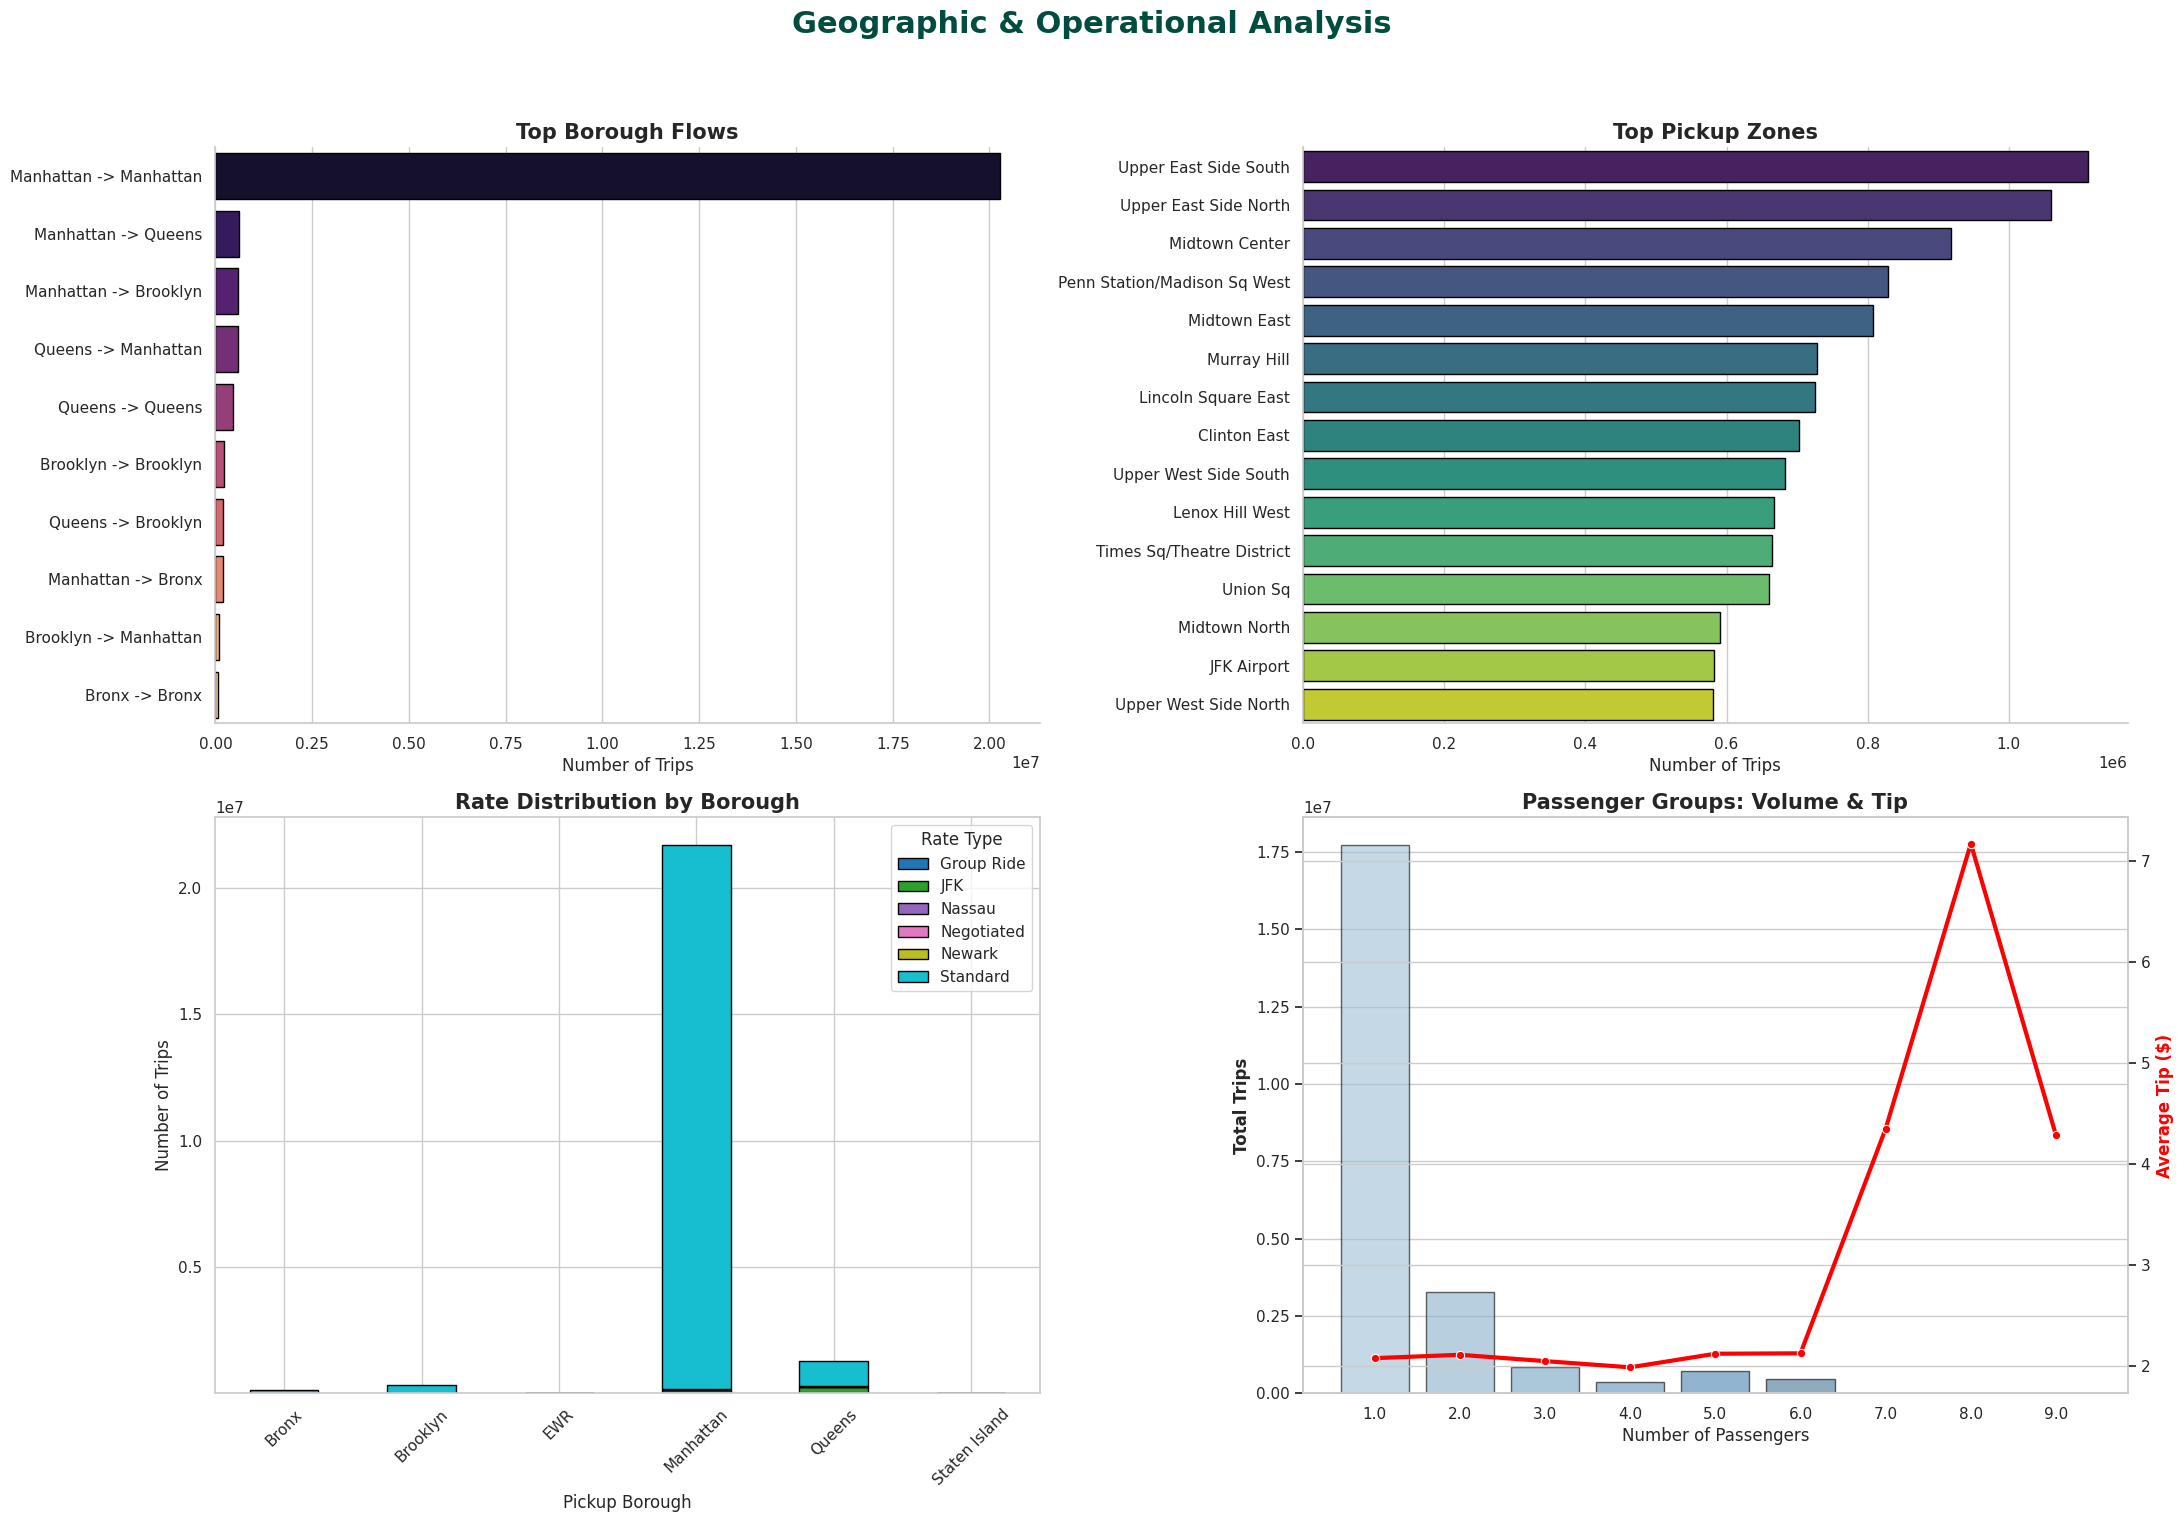

In [20]:
# 1. ROUTES (Top Borough Flows)
taxi_df_routes = taxi_df.withColumn(
    "route",
    concat(
        col("PU_Borough"),
        lit(" -> "),
        col("DO_Borough")
    )
)

route_data = taxi_df_routes.groupBy("route") \
    .count() \
    .orderBy("count", ascending=False) \
    .limit(10) \
    .toPandas()

# 2. TOP ZONES
top_zones = taxi_df.groupBy("PU_Zone") \
    .count() \
    .orderBy("count", ascending=False) \
    .limit(15) \
    .toPandas()

# 3. RATE CODES
taxi_df_rates = taxi_df.withColumn(
    "RateName",
    when(col("RatecodeID") == 1, "Standard")
    .when(col("RatecodeID") == 2, "JFK")
    .when(col("RatecodeID") == 3, "Newark")
    .when(col("RatecodeID") == 4, "Nassau")
    .when(col("RatecodeID") == 5, "Negotiated")
    .otherwise("Group Ride")
)

rate_dist = taxi_df_rates.groupBy(
    "PU_Borough",
    "RateName"
).count().toPandas()

rate_pivot = rate_dist.pivot(
    index="PU_Borough",
    columns="RateName",
    values="count"
).fillna(0)

# 4. PASSENGER GROUPS (Volume & Tip)
pass_group_data = taxi_df.groupBy("passenger_count") \
    .agg(
        avg("tip_amount").alias("avg_tip"),
        spark_count("*").alias("trip_count")
    ) \
    .orderBy("passenger_count") \
    .toPandas()


# PLOTS
fig, ax = plt.subplots(2, 2, figsize=(22, 16))
fig.suptitle('Geographic & Operational Analysis', fontsize=22, fontweight='bold', color='#004d40')

# Top Left: Top routes
sns.barplot(
    data=route_data,
    x="count",
    y="route",
    palette="magma",
    edgecolor="black",
    ax=ax[0,0]
)
ax[0,0].set_title("Top Borough Flows", fontsize=15, fontweight='bold')
ax[0,0].set_xlabel("Number of Trips", fontsize=12)
ax[0,0].set_ylabel("")

# Top Right: Top zones
sns.barplot(
    data=top_zones,
    x="count",
    y="PU_Zone",
    palette="viridis",
    edgecolor="black",
    ax=ax[0,1]
)
ax[0,1].set_title("Top Pickup Zones", fontsize=15, fontweight='bold')
ax[0,1].set_xlabel("Number of Trips", fontsize=12)
ax[0,1].set_ylabel("")

# Bottom Left: Stacked rate plot
rate_pivot.plot(
    kind='bar',
    stacked=True,
    colormap="tab10",
    edgecolor="black",
    ax=ax[1,0]
)
ax[1,0].set_title("Rate Distribution by Borough", fontsize=15, fontweight='bold')
ax[1,0].set_xlabel("Pickup Borough", fontsize=12)
ax[1,0].set_ylabel("Number of Trips", fontsize=12)
ax[1,0].legend(title="Rate Type", title_fontsize='12', fontsize='11')
ax[1,0].tick_params(axis='x', rotation=45)

# Bottom Right: Passenger Groups (Dual Axis)
sns.barplot(
    data=pass_group_data,
    x="passenger_count",
    y="trip_count",
    alpha=0.6,
    palette="Blues_d",
    edgecolor="black",
    ax=ax[1,1]
)
ax[1,1].set_ylabel("Total Trips", fontsize=12, fontweight='bold')
ax[1,1].set_xlabel("Number of Passengers", fontsize=12)

ax2 = ax[1,1].twinx()
sns.lineplot(
    data=pass_group_data,
    x=ax[1,1].get_xticks(),
    y="avg_tip",
    marker="o",
    color="red",
    linewidth=3,
    ax=ax2
)
ax2.set_ylabel("Average Tip ($)", fontsize=12, fontweight='bold', color="red")

ax[1,1].set_title("Passenger Groups: Volume & Tip", fontsize=15, fontweight='bold')

for axes in [ax[0,0], ax[0,1]]:
    axes.spines['top'].set_visible(False)
    axes.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Financials, Payments & Revenue Behaviour

Aggregating financial data...


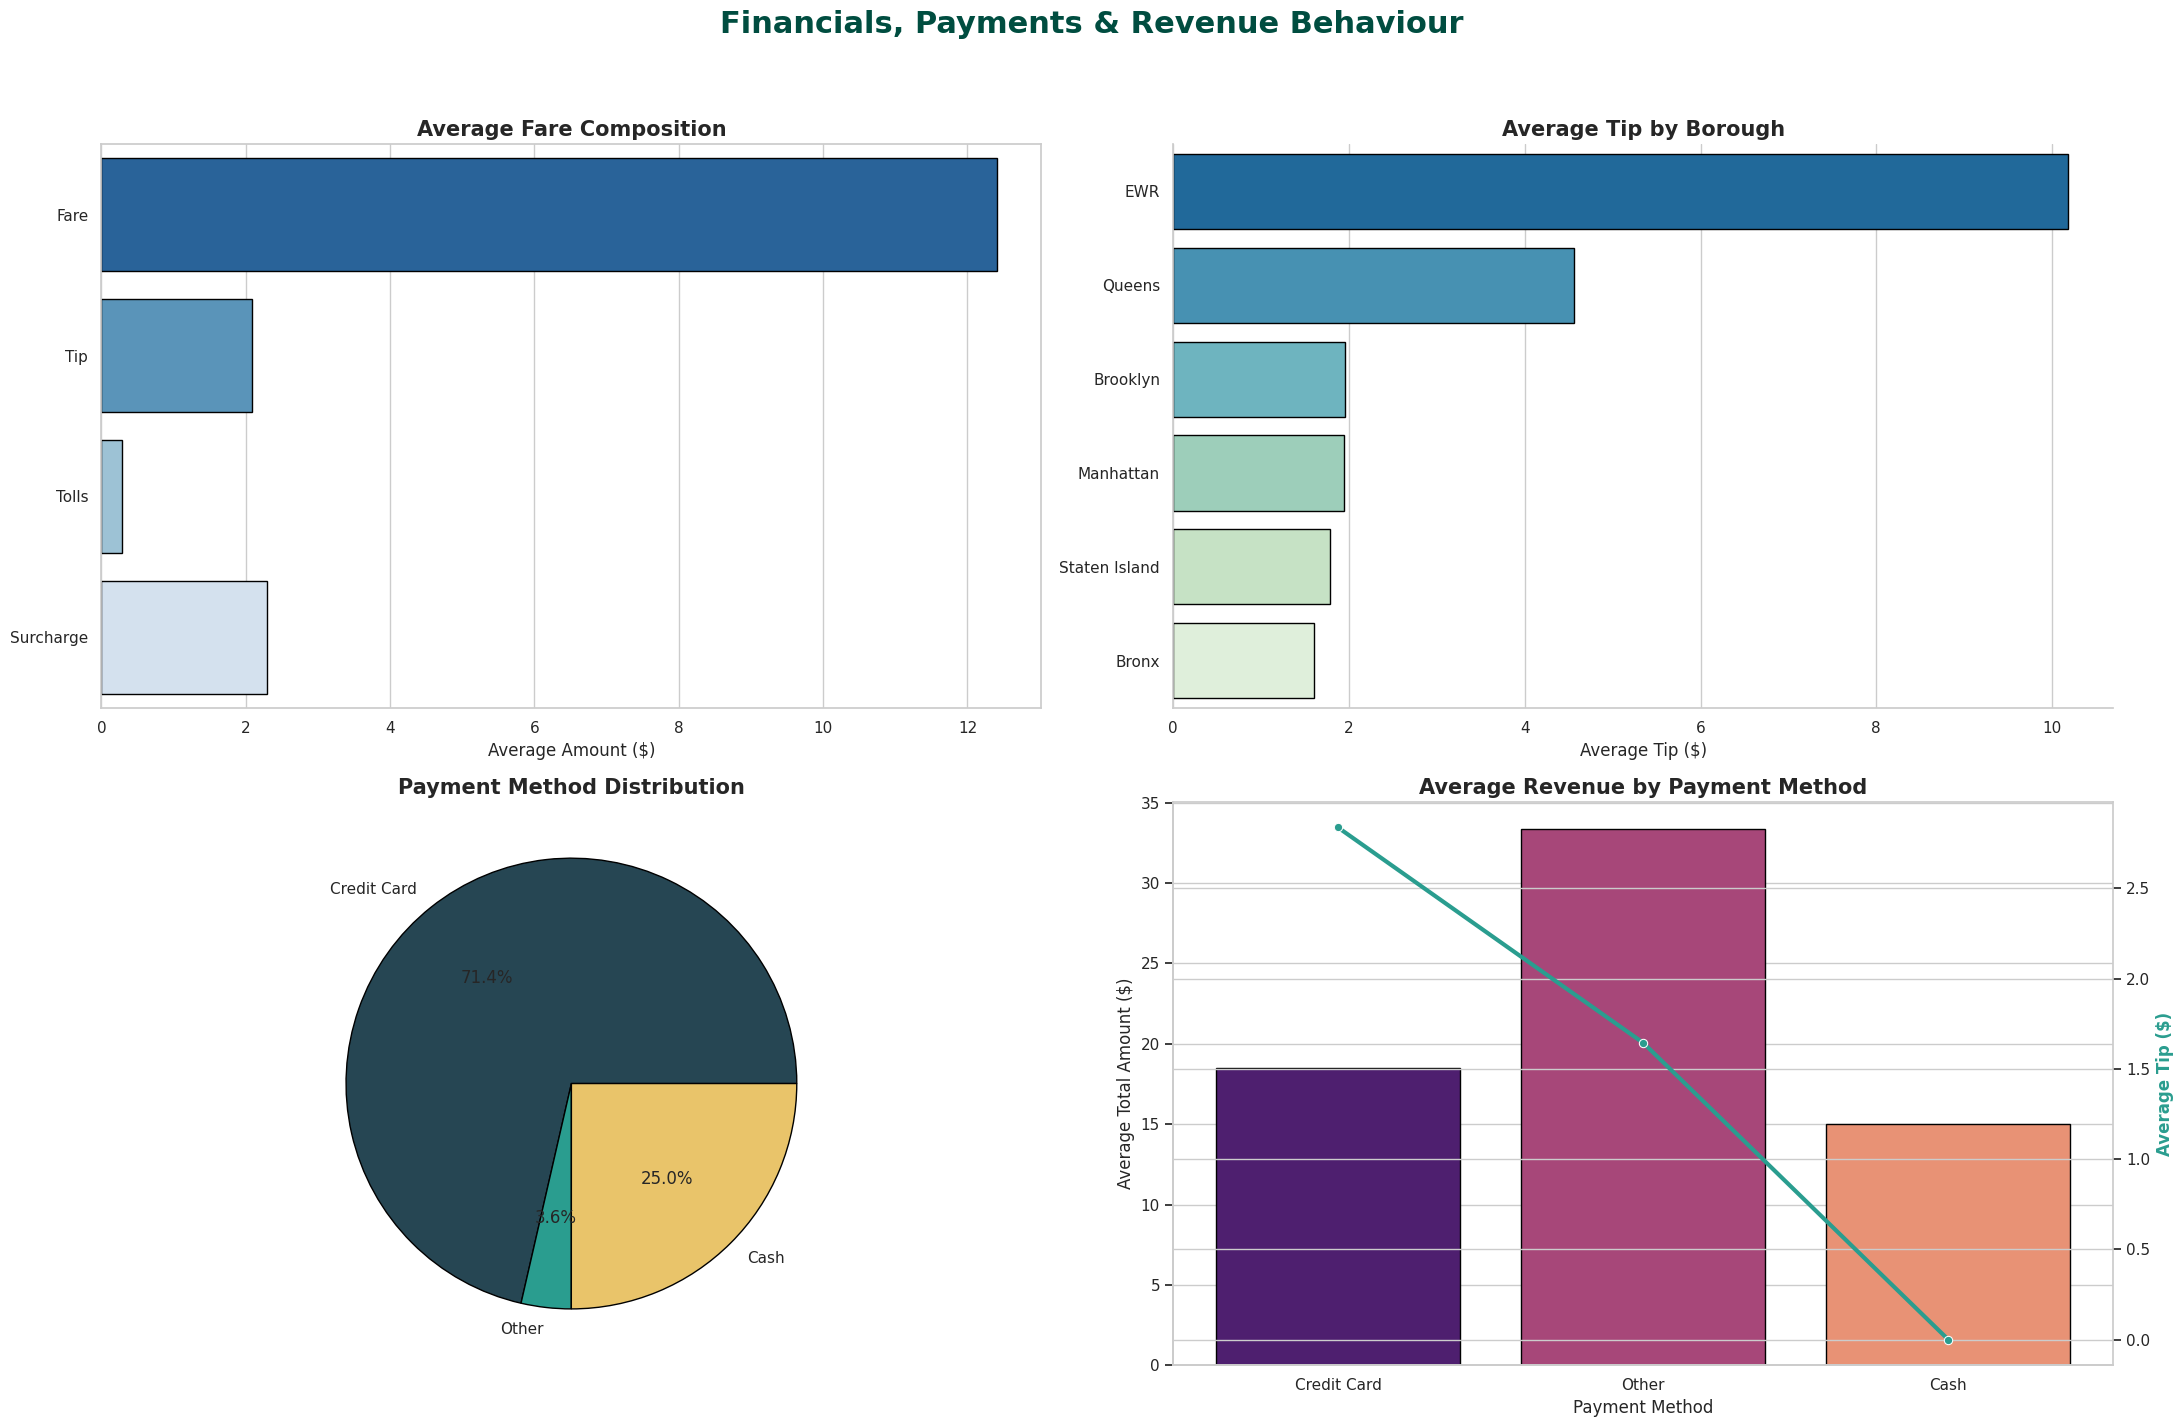

In [21]:
from pyspark.sql.functions import avg, col, when

import matplotlib.pyplot as plt
import seaborn as sns

# 1. FEATURE ENGINEERING

taxi_df_fin = taxi_df.withColumn(
    "distance_category",
    when(col("trip_distance") < 2, "1. Short (<2m)")
    .when((col("trip_distance") >= 2) & (col("trip_distance") < 5), "2. Medium (2-5m)")
    .when((col("trip_distance") >= 5) & (col("trip_distance") < 10), "3. Long (5-10m)")
    .otherwise("4. Very Long (>10m)")
).withColumn(
    "payment_name",
    when(col("payment_type") == 1, "Credit Card")
    .when(col("payment_type") == 2, "Cash")
    .otherwise("Other")
)

# 2. AGGREGATIONS
print("Aggregating financial data...")

# 1. Fare composition
finance_avg = taxi_df_fin.selectExpr(
    "avg(fare_amount) as Fare",
    "avg(tip_amount) as Tip",
    "avg(tolls_amount) as Tolls",
    "avg(congestion_surcharge) as Surcharge"
).toPandas()

# 2. Tip by borough
tip_borough = taxi_df_fin.groupBy("PU_Borough") \
    .agg(avg("tip_amount").alias("avg_tip")) \
    .orderBy("avg_tip", ascending=False) \
    .toPandas()

# 3. Payment distribution
payment_dist = taxi_df_fin.groupBy("payment_name") \
    .count() \
    .toPandas()

# 4. Revenue by payment method (NOVO GRÁFICO)
payment_revenue = taxi_df_fin.groupBy("payment_name") \
    .agg(
        avg("total_amount").alias("avg_total"),
        avg("tip_amount").alias("avg_tip")
    ) \
    .toPandas()

# 3. PLOTS
fig, ax = plt.subplots(2, 2, figsize=(22, 15))

fig.suptitle(
    'Financials, Payments & Revenue Behaviour',
    fontsize=22,
    fontweight='bold',
    color='#004d40'
)

# Top Left: Fare composition
finance_long = finance_avg.T.reset_index()
finance_long.columns = ['component', 'avg_value']

sns.barplot(
    data=finance_long,
    y='component',
    x='avg_value',
    ax=ax[0, 0],
    palette="Blues_r",
    edgecolor="black"
)

ax[0, 0].set_ylabel("")
ax[0, 0].set_xlabel("Average Amount ($)", fontsize=12)
ax[0, 0].set_title(
    "Average Fare Composition",
    fontsize=15,
    fontweight='bold'
)

# Top Right: Tip by Borough
sns.barplot(
    data=tip_borough,
    x="avg_tip",
    y="PU_Borough",
    palette="GnBu_r",
    edgecolor="black",
    ax=ax[0, 1]
)

ax[0, 1].set_title(
    "Average Tip by Borough",
    fontsize=15,
    fontweight='bold'
)

ax[0, 1].set_xlabel("Average Tip ($)", fontsize=12)
ax[0, 1].set_ylabel("")

# Bottom Left: Payment Method Distribution
ax[1, 0].pie(
    payment_dist['count'],
    labels=payment_dist['payment_name'],
    autopct='%1.1f%%',
    colors=['#264653', '#2a9d8f', '#e9c46a'],
    wedgeprops={'edgecolor': 'black'}
)

ax[1, 0].set_title(
    "Payment Method Distribution",
    fontsize=15,
    fontweight='bold'
)

# Bottom Right: Revenue by Payment Method
sns.barplot(
    data=payment_revenue,
    x="payment_name",
    y="avg_total",
    palette="magma",
    edgecolor="black",
    ax=ax[1, 1]
)

ax[1, 1].set_title(
    "Average Revenue by Payment Method",
    fontsize=15,
    fontweight='bold'
)

ax[1, 1].set_xlabel("Payment Method", fontsize=12)
ax[1, 1].set_ylabel("Average Total Amount ($)", fontsize=12)

ax2 = ax[1, 1].twinx()

sns.lineplot(
    data=payment_revenue,
    x=ax[1, 1].get_xticks(),
    y="avg_tip",
    marker="o",
    color="#2a9d8f",
    linewidth=3,
    ax=ax2
)

ax2.set_ylabel(
    "Average Tip ($)",
    fontsize=12,
    fontweight='bold',
    color="#2a9d8f"
)

for axes in [ax[0, 1], ax[1, 1]]:
    axes.spines['top'].set_visible(False)
    axes.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Operational & Financial Relationships

Preparing scatter dashboard data...


Sample size: 46,977


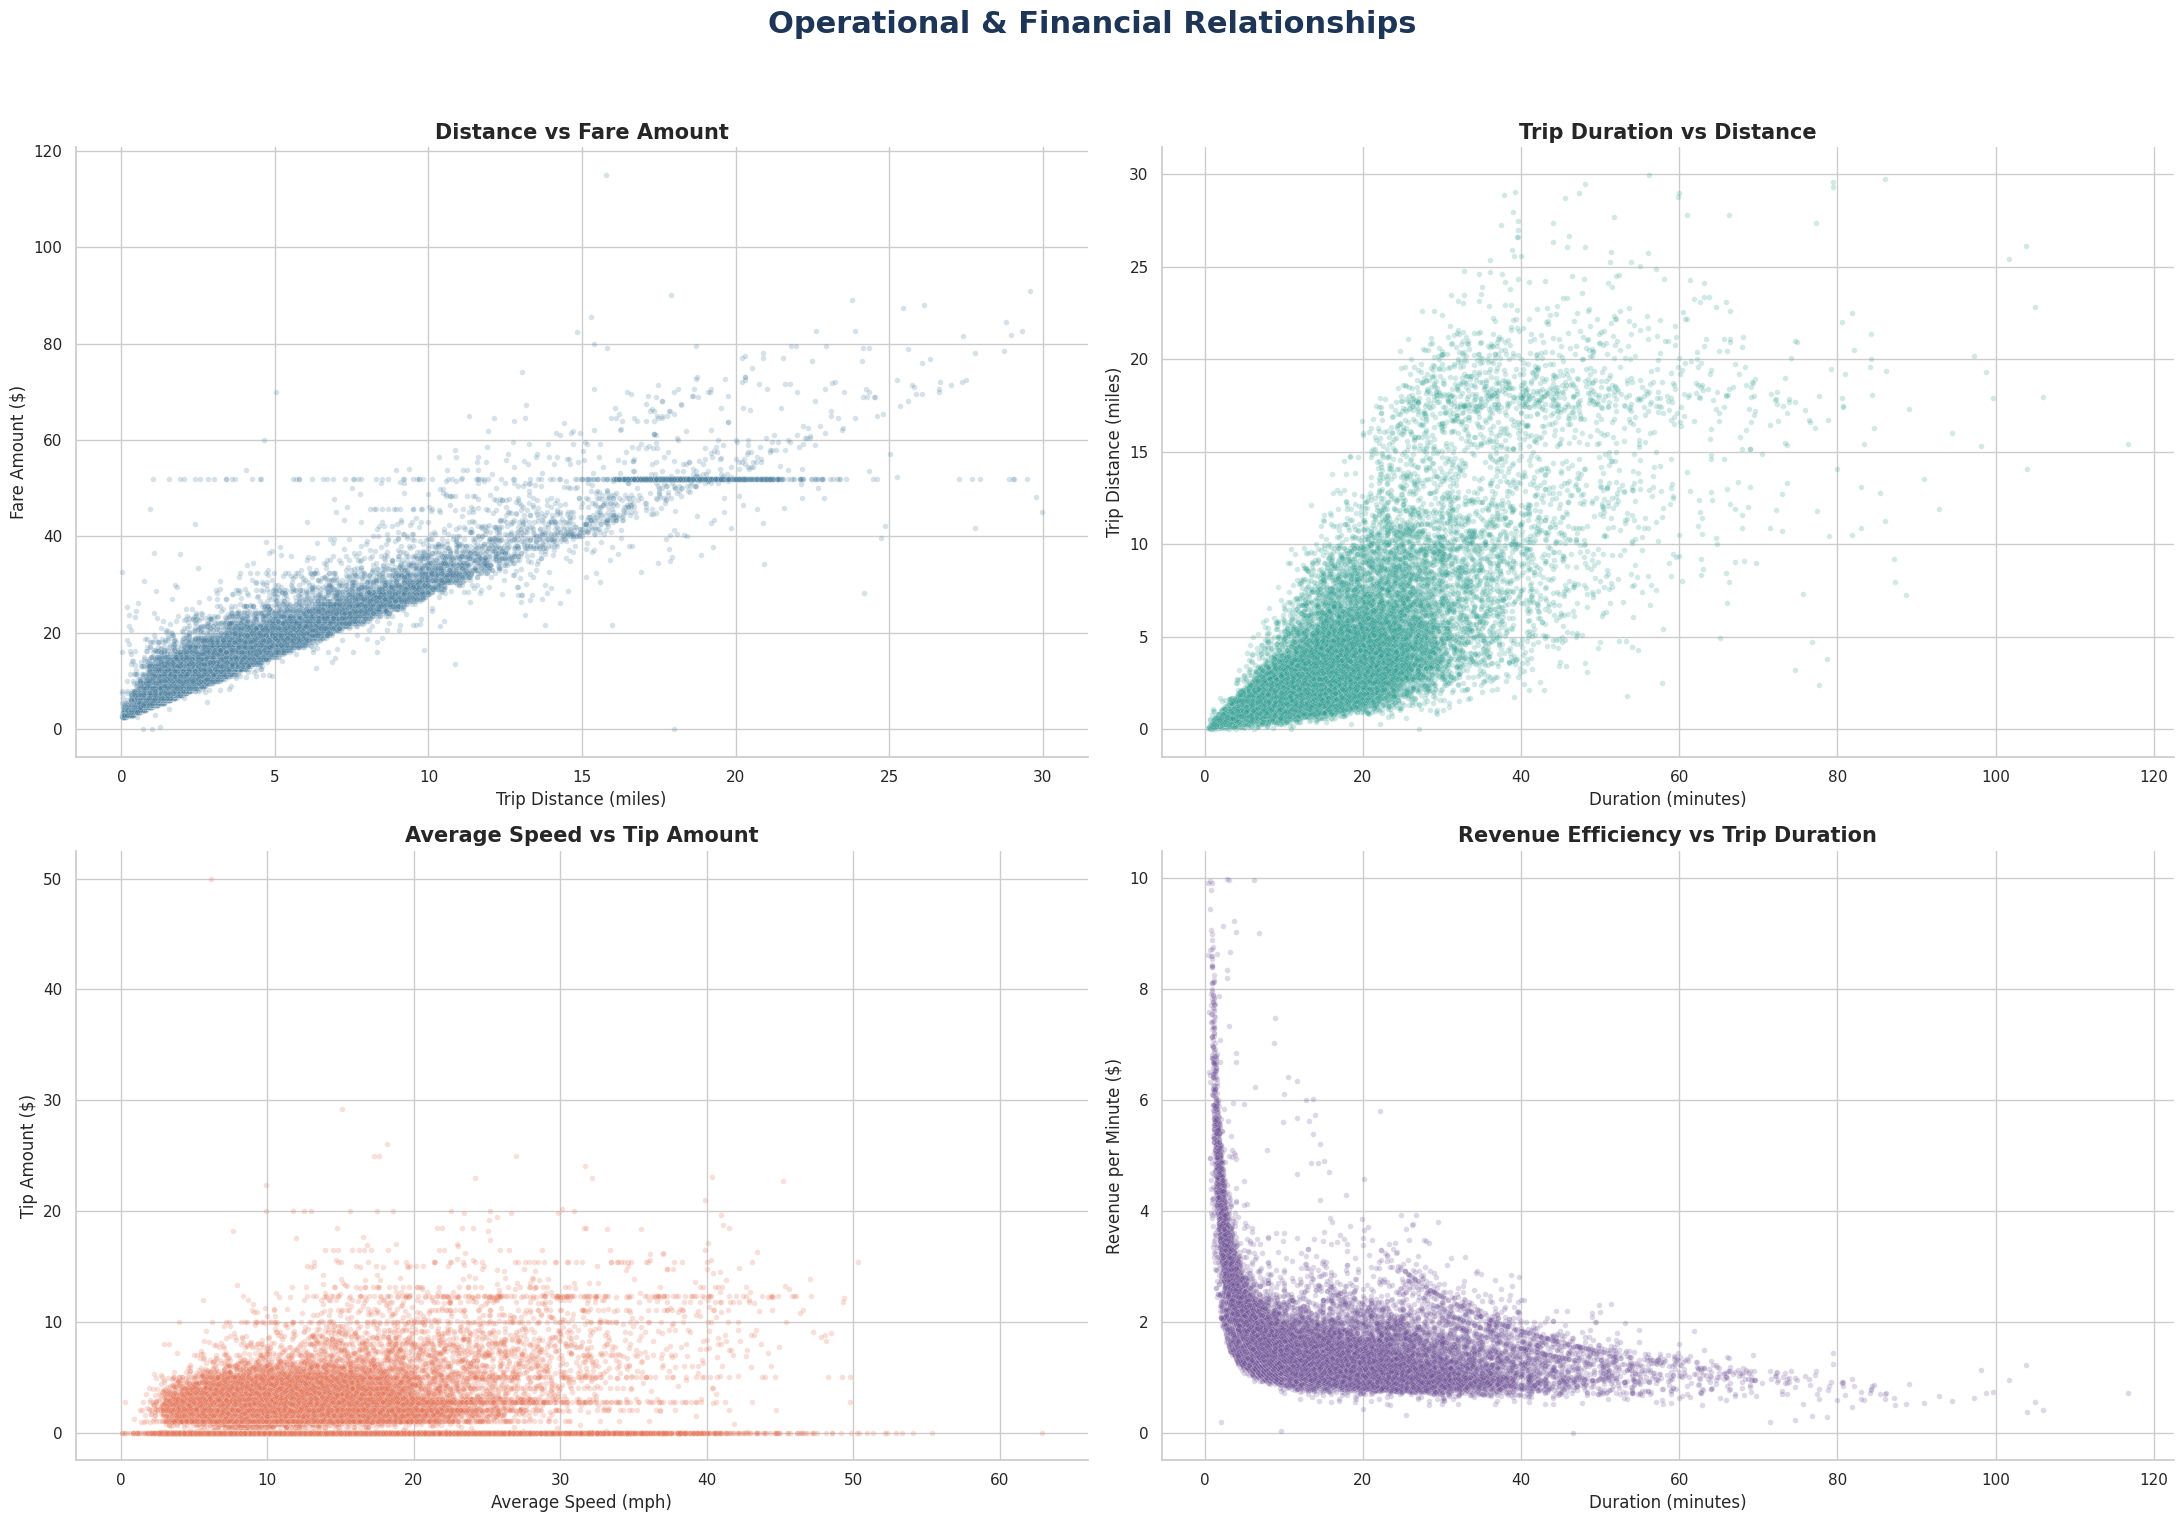

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pyspark.sql.functions import (
    col,
    unix_timestamp
)

# 1. FEATURE ENGINEERING
print("Preparing scatter dashboard data...")

taxi_df_scatter = taxi_df.withColumn(
    "duration_m",
    (
        unix_timestamp("tpep_dropoff_datetime") -
        unix_timestamp("tpep_pickup_datetime")
    ) / 60
)

# Average speed (mph)
taxi_df_scatter = taxi_df_scatter.withColumn(
    "speed_mph",
    col("trip_distance") / (col("duration_m") / 60)
)

# Revenue efficiency ($ per minute)
taxi_df_scatter = taxi_df_scatter.withColumn(
    "revenue_per_min",
    col("total_amount") / col("duration_m")
)

# 2. DATA CLEANING

taxi_df_scatter = taxi_df_scatter.filter(
    (col("trip_distance") > 0) &
    (col("trip_distance") <= 30) &

    (col("fare_amount") > 0) &
    (col("fare_amount") <= 150) &

    (col("duration_m") > 0) &
    (col("duration_m") <= 120) &

    (col("speed_mph") > 0) &
    (col("speed_mph") <= 70) &
    (col("tip_amount") >= 0) &
    (col("tip_amount") <= 50) &

    (col("total_amount") > 0) &

    (col("revenue_per_min") > 0) &
    (col("revenue_per_min") <= 10)
)

# 3. SAMPLING
# IMPORTANT: Never plot 24M rows directly

sample_pd = taxi_df_scatter.select(
    "trip_distance",
    "fare_amount",
    "duration_m",
    "speed_mph",
    "tip_amount",
    "revenue_per_min"
).sample(0.002).toPandas()

print(f"Sample size: {len(sample_pd):,}")

# 4. VISUALIZATION
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(2, 2, figsize=(22, 16))

fig.suptitle(
    'Operational & Financial Relationships',
    fontsize=22,
    fontweight='bold',
    color='#1d3557'
)

# TOP LEFT — Distance vs Fare
sns.scatterplot(
    data=sample_pd,
    x="trip_distance",
    y="fare_amount",
    alpha=0.22,
    s=16,
    color="#457b9d",
    ax=ax[0,0]
)

ax[0,0].set_title(
    "Distance vs Fare Amount",
    fontsize=15,
    fontweight='bold'
)

ax[0,0].set_xlabel(
    "Trip Distance (miles)",
    fontsize=12
)

ax[0,0].set_ylabel(
    "Fare Amount ($)",
    fontsize=12
)

# TOP RIGHT — Duration vs Distance
sns.scatterplot(
    data=sample_pd,
    x="duration_m",
    y="trip_distance",
    alpha=0.22,
    s=16,
    color="#2a9d8f",
    ax=ax[0,1]
)

ax[0,1].set_title(
    "Trip Duration vs Distance",
    fontsize=15,
    fontweight='bold'
)

ax[0,1].set_xlabel(
    "Duration (minutes)",
    fontsize=12
)

ax[0,1].set_ylabel(
    "Trip Distance (miles)",
    fontsize=12
)

# BOTTOM LEFT — Speed vs Tip

sns.scatterplot(
    data=sample_pd,
    x="speed_mph",
    y="tip_amount",
    alpha=0.22,
    s=16,
    color="#e76f51",
    ax=ax[1,0]
)

ax[1,0].set_title(
    "Average Speed vs Tip Amount",
    fontsize=15,
    fontweight='bold'
)

ax[1,0].set_xlabel(
    "Average Speed (mph)",
    fontsize=12
)

ax[1,0].set_ylabel(
    "Tip Amount ($)",
    fontsize=12
)

# BOTTOM RIGHT — Revenue vs Duration
sns.scatterplot(
    data=sample_pd,
    x="duration_m",
    y="revenue_per_min",
    alpha=0.22,
    s=16,
    color="#6a4c93",
    ax=ax[1,1]
)

ax[1,1].set_title(
    "Revenue Efficiency vs Trip Duration",
    fontsize=15,
    fontweight='bold'
)

ax[1,1].set_xlabel(
    "Duration (minutes)",
    fontsize=12
)

ax[1,1].set_ylabel(
    "Revenue per Minute ($)",
    fontsize=12
)

for axes in [ax[0,0], ax[0,1], ax[1,0], ax[1,1]]:

    axes.spines['top'].set_visible(False)
    axes.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Correlation Analysis

26/05/12 23:00:24 WARN YarnAllocator: Container from a bad node: container_1778622189177_0001_01_000003 on host: cluster-taxi-w-0.us-east1-c.c.project-c42ab676-7327-4ef1-8b7.internal. Exit status: 143. Diagnostics: [2026-05-12 23:00:24.238]Container killed on request. Exit code is 143
[2026-05-12 23:00:24.238]Container exited with a non-zero exit code 143. 
[2026-05-12 23:00:24.239]Killed by external signal
.
26/05/12 23:00:24 ERROR YarnScheduler: Lost executor 3 on cluster-taxi-w-0.us-east1-c.c.project-c42ab676-7327-4ef1-8b7.internal: Container from a bad node: container_1778622189177_0001_01_000003 on host: cluster-taxi-w-0.us-east1-c.c.project-c42ab676-7327-4ef1-8b7.internal. Exit status: 143. Diagnostics: [2026-05-12 23:00:24.238]Container killed on request. Exit code is 143
[2026-05-12 23:00:24.238]Container exited with a non-zero exit code 143. 
[2026-05-12 23:00:24.239]Killed by external signal
.
26/05/12 23:00:24 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting drive

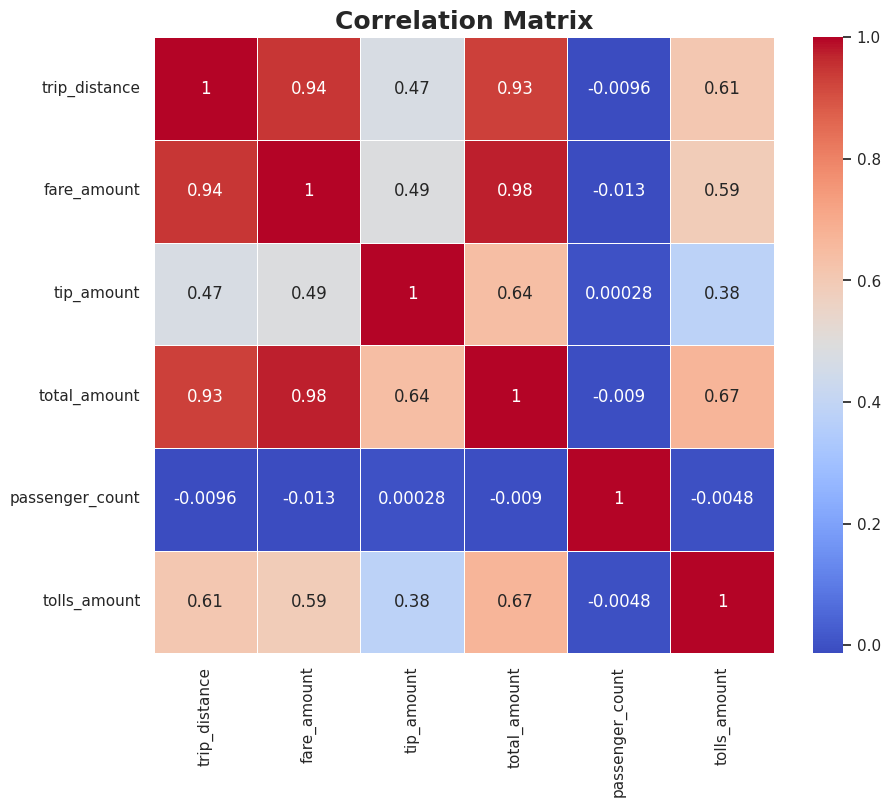

In [23]:
corr_cols = [
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "passenger_count",
    "tolls_amount"
]

corr_pd = taxi_df.select(corr_cols) \
    .sample(0.01) \
    .toPandas()

corr_matrix = corr_pd.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix",
    fontsize=18,
    fontweight='bold'
)

plt.show()

## **Queries**

In [24]:
import time
import psutil
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def get_memory_mb():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / 1024**2

### Query 1

In [25]:
start_time = time.time()
mem_before = get_memory_mb()

q1_df_api = taxi_df.groupBy("payment_name") \
    .agg(avg("tip_amount").alias("avg_tip")) \
    .orderBy("avg_tip", ascending=False)

q1_result = q1_df_api.toPandas()

time_df = time.time() - start_time
mem_df = get_memory_mb() - mem_before

In [26]:
taxi_df.createOrReplaceTempView("taxi")

start_time = time.time()
mem_before = get_memory_mb()

q1_sql = spark.sql("""
SELECT payment_name,
       AVG(tip_amount) AS avg_tip
FROM taxi
GROUP BY payment_name
ORDER BY avg_tip DESC
""")

q1_sql_result = q1_sql.toPandas()

time_sql = time.time() - start_time
mem_sql = get_memory_mb() - mem_before

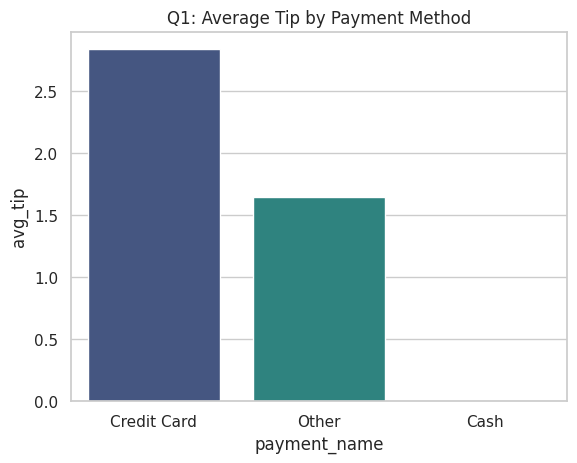

In [27]:
sns.barplot(data=q1_result, x="payment_name", y="avg_tip", palette="viridis")
plt.title("Q1: Average Tip by Payment Method")
plt.show()

### Query 2

In [28]:
start_time = time.time()
mem_before = get_memory_mb()

q2_df_api = taxi_df.filter(col("fare_amount") > 0) \
    .withColumn("tip_pct", (col("tip_amount") / col("fare_amount")) * 100) \
    .groupBy("PU_Borough") \
    .agg(
        avg("tip_pct").alias("avg_tip_pct"),
        avg("total_amount").alias("avg_total")
    ) \
    .orderBy("avg_total", ascending=False)

q2_result = q2_df_api.toPandas()

time_df = time.time() - start_time
mem_df = get_memory_mb() - mem_before

In [29]:
start_time = time.time()
mem_before = get_memory_mb()

q2_sql = spark.sql("""
SELECT PU_Borough,
       AVG((tip_amount / fare_amount) * 100) AS avg_tip_pct,
       AVG(total_amount) AS avg_total
FROM taxi
WHERE fare_amount > 0
GROUP BY PU_Borough
ORDER BY avg_total DESC
""")

q2_sql_result = q2_sql.toPandas()

time_sql = time.time() - start_time
mem_sql = get_memory_mb() - mem_before

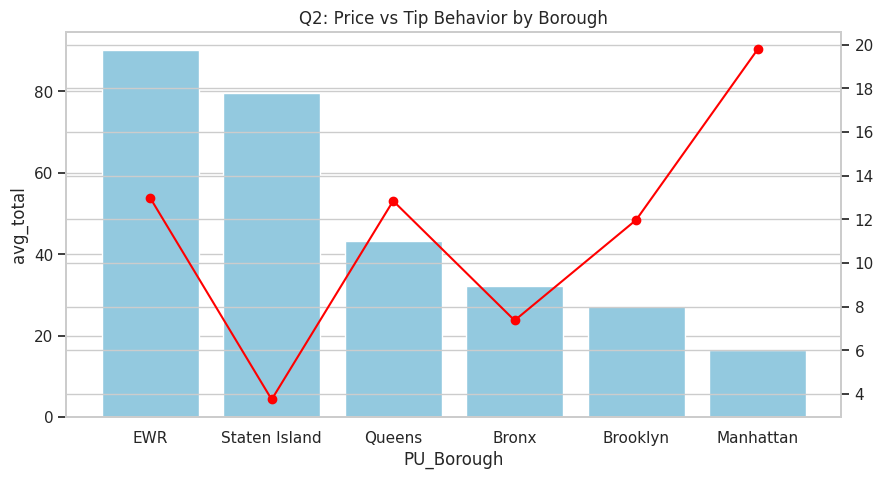

In [30]:
fig, ax1 = plt.subplots(figsize=(10,5))

sns.barplot(data=q2_result, x="PU_Borough", y="avg_total", ax=ax1, color="skyblue")

ax2 = ax1.twinx()
ax2.plot(q2_result["PU_Borough"], q2_result["avg_tip_pct"], color="red", marker="o")

plt.title("Q2: Price vs Tip Behavior by Borough")
plt.show()

### Query 3

In [31]:
start_time = time.time()
mem_before = get_memory_mb()

q3_df_api = taxi_df.filter(col("fare_amount") > 0) \
    .withColumn("tip_pct", col("tip_amount") / col("fare_amount") * 100) \
    .groupBy("hour") \
    .agg(avg("tip_pct").alias("avg_tip_pct"))

q3_result = q3_df_api.toPandas()

time_df = time.time() - start_time
mem_df = get_memory_mb() - mem_before

In [ ]:
start_time = time.time()
mem_before = get_memory_mb()

q3_sql = spark.sql("""
SELECT hour,
       AVG((tip_amount / fare_amount) * 100) AS avg_tip_pct
FROM taxi
WHERE fare_amount > 0
GROUP BY hour
ORDER BY hour
""")

q3_sql_result = q3_sql.toPandas()

time_sql = time.time() - start_time
mem_sql = get_memory_mb() - mem_before

In [ ]:
sns.lineplot(data=q3_result, x="hour", y="avg_tip_pct", marker="o")
plt.title("Q3: Tip Percentage by Hour")
plt.show()

### Query 4

In [ ]:
start_time = time.time()
mem_before = get_memory_mb()

q4_df_api = taxi_df.filter(col("fare_amount") > 0) \
    .withColumn("tip_pct", col("tip_amount") / col("fare_amount") * 100) \
    .withColumn(
        "distance_category",
        when(col("trip_distance") < 2, "Short")
        .when(col("trip_distance") < 5, "Medium")
        .otherwise("Long")
    ) \
    .groupBy("PU_Borough", "distance_category", "payment_name") \
    .agg(
        avg("tip_pct").alias("avg_tip_pct"),
        avg("total_amount").alias("avg_total")
    )

q4_result = q4_df_api.toPandas()

time_df = time.time() - start_time
mem_df = get_memory_mb() - mem_before

In [ ]:
start_time = time.time()
mem_before = get_memory_mb()

q4_sql = spark.sql("""
SELECT PU_Borough,
       CASE 
         WHEN trip_distance < 2 THEN 'Short'
         WHEN trip_distance < 5 THEN 'Medium'
         ELSE 'Long'
       END AS distance_category,
       payment_name,
       AVG((tip_amount / fare_amount) * 100) AS avg_tip_pct,
       AVG(total_amount) AS avg_total
FROM taxi
WHERE fare_amount > 0
GROUP BY PU_Borough, distance_category, payment_name
""")

q4_sql_result = q4_sql.toPandas()

time_sql = time.time() - start_time
mem_sql = get_memory_mb() - mem_before

In [ ]:
pivot = q4_result.pivot_table(
    index="PU_Borough",
    columns="distance_category",
    values="avg_tip_pct"
)

sns.heatmap(pivot, annot=True, cmap="YlGnBu")
plt.title("Q4: Tip Generosity by Borough & Distance")
plt.show()

Join

In [ ]:
benchmark = pd.DataFrame({
    "query": ["Q1","Q2","Q3","Q4"],
    "df_time": [time_df, time_df, time_df, time_df],
    "sql_time": [time_sql, time_sql, time_sql, time_sql],
    "df_mem": [mem_df, mem_df, mem_df, mem_df],
    "sql_mem": [mem_sql, mem_sql, mem_sql, mem_sql]
})

In [ ]:
print(benchmark)

In [ ]:
import time
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.window import Window
from pyspark.sql.functions import sum as spark_sum, row_number, desc, col

# =====================================================================
# 0. REGISTAR O DATAFRAME NO MOTOR SQL (A peça que faltava!)
# =====================================================================
taxi_df.createOrReplaceTempView("taxi_data")


# =====================================================================
# 1. PySpark DataFrame API
# =====================================================================
start_time = time.time()

# Passo 1: Agregar a faturação total por rota
route_agg = taxi_df.groupBy("PU_Borough", "DO_Borough") \
    .agg(spark_sum("total_amount").alias("total_revenue"))

# Passo 2: Definir a Window para ranquear as rotas dentro de cada Bairro de Origem
windowSpec = Window.partitionBy("PU_Borough").orderBy(desc("total_revenue"))

# Passo 3: Aplicar o Row_Number e filtrar os Top 3
q4_df_spark = route_agg.withColumn("rank", row_number().over(windowSpec)) \
    .filter(col("rank") <= 3)

q4_spark_res = q4_df_spark.toPandas()
print(f"Tempo PySpark: {time.time() - start_time:.4f} segundos")


# =====================================================================
# 2. Spark SQL
# =====================================================================
start_time = time.time()
q4_sql = spark.sql("""
    WITH RouteAgg AS (
        SELECT 
            PU_Borough, 
            DO_Borough, 
            SUM(total_amount) as total_revenue
        FROM taxi_data
        GROUP BY PU_Borough, DO_Borough
    ),
    RankedRoutes AS (
        SELECT 
            *,
            ROW_NUMBER() OVER(PARTITION BY PU_Borough ORDER BY total_revenue DESC) as rank
        FROM RouteAgg
    )
    SELECT * FROM RankedRoutes WHERE rank <= 3
""")
q4_sql_res = q4_sql.toPandas()
print(f"Tempo Spark SQL: {time.time() - start_time:.4f} segundos")


# =====================================================================
# 3. VISUALIZAÇÃO
# =====================================================================
plt.figure(figsize=(14, 8))

# Vamos criar uma string única de rota para facilitar o plot
q4_spark_res['Route'] = q4_spark_res['PU_Borough'] + ' ➔ ' + q4_spark_res['DO_Borough']

# Ordenar para o gráfico ficar com as barras organizadas por bairro e rank
q4_spark_res = q4_spark_res.sort_values(by=['PU_Borough', 'rank'])

sns.barplot(data=q4_spark_res, y="Route", x="total_revenue", hue="PU_Borough", dodge=False, palette="Set1", edgecolor="black")
plt.title("As 3 Rotas mais Lucrativas por cada Bairro de Origem", fontsize=16, fontweight='bold')
plt.xlabel("Faturação Total Acumulada ($)", fontsize=12)
plt.ylabel("Rota (Origem ➔ Destino)", fontsize=12)
plt.legend(title="Bairro de Origem", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
from pyspark.sql.functions import expr

# =====================================================================
# 1. PySpark DataFrame API
# =====================================================================
start_time = time.time()

# Usar expr() para executar funções Spark SQL complexas dentro do PySpark API
q6_df_spark = taxi_df.filter(col("payment_type") == 1) \
    .withColumn("route", expr("concat(PU_Borough, ' -> ', DO_Borough)")) \
    .groupBy("route") \
    .agg(
        expr("count(*)").alias("total_trips"),
        expr("percentile_approx(speed_mph, 0.90, 100)").alias("p90_speed_mph"),
        expr("percentile_approx(tip_pct, 0.50, 100)").alias("median_tip_pct"),
        expr("sum(case when tolls_amount > 0 then 1 else 0 end) / count(*) * 100").alias("toll_probability")
    ).filter(col("total_trips") > 10000) \
    .orderBy(col("total_trips").desc()) \
    .limit(15)

q6_spark_res = q6_df_spark.toPandas()
print(f"Tempo PySpark (Percentis): {time.time() - start_time:.4f} segundos")

# =====================================================================
# 2. Spark SQL
# =====================================================================
start_time = time.time()
q6_sql = spark.sql("""
    SELECT 
        concat(PU_Borough, ' -> ', DO_Borough) as route,
        count(*) as total_trips,
        percentile_approx(speed_mph, 0.90, 100) as p90_speed_mph,
        percentile_approx(tip_pct, 0.50, 100) as median_tip_pct,
        (sum(case when tolls_amount > 0 then 1 else 0 end) / count(*)) * 100 as toll_probability
    FROM taxi_data
    WHERE payment_type = 1
    GROUP BY route
    HAVING total_trips > 10000
    ORDER BY total_trips DESC
    LIMIT 15
""")
q6_sql_res = q6_sql.toPandas()
print(f"Tempo Spark SQL (Percentis): {time.time() - start_time:.4f} segundos")

# =====================================================================
# 3. VISUALIZAÇÃO
# =====================================================================
plt.figure(figsize=(14, 8))
# Scatter plot onde X é Velocidade, Y é Gorjeta, o tamanho da bolha é a Probabilidade de Portagem
scatter = sns.scatterplot(
    data=q6_spark_res, x="p90_speed_mph", y="median_tip_pct", 
    size="toll_probability", sizes=(100, 1500), hue="route", 
    palette="tab20", alpha=0.7, edgecolor="black"
)

plt.title("Matriz de Performance (Top 15 Rotas): Velocidade Extrema vs Mediana de Gorjeta", fontsize=16, fontweight='bold')
plt.xlabel("Velocidade no 90º Percentil (mph)", fontsize=12)
plt.ylabel("Mediana da Gorjeta (%)", fontsize=12)

# Adicionar o nome da rota perto da bolha
for i in range(q6_spark_res.shape[0]):
    plt.text(q6_spark_res.p90_speed_mph[i]+0.5, q6_spark_res.median_tip_pct[i], 
             q6_spark_res.route[i], horizontalalignment='left', size='small', color='black')

# Ocultar a legenda gigante gerada pelas rotas
handles, labels = scatter.get_legend_handles_labels()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title="Tamanho = Probabilidade de Portagem (%)")

plt.tight_layout()
plt.show()

In [ ]:
from pyspark.sql.functions import row_number, rank

# =====================================================================
# 1. PySpark DataFrame API
# =====================================================================
start_time = time.time()

# 1. Total faturado por Zona em cada Hora
zone_hourly = taxi_df.groupBy("hour", "PU_Zone").agg(spark_sum("total_amount").alias("zone_revenue"))

# 2. Window para o Total de NYC na mesma Hora e Cálculo da Percentagem
hour_window = Window.partitionBy("hour")
zone_dominance = zone_hourly.withColumn("total_nyc_revenue", spark_sum("zone_revenue").over(hour_window)) \
    .withColumn("dominance_pct", (col("zone_revenue") / col("total_nyc_revenue")) * 100)

# 3. Window para Ranqueamento e Filtro do Top 1
rank_window = Window.partitionBy("hour").orderBy(col("zone_revenue").desc())
q7_df_spark = zone_dominance.withColumn("rank", row_number().over(rank_window)) \
    .filter(col("rank") == 1) \
    .orderBy("hour")

q7_spark_res = q7_df_spark.toPandas()
print(f"Tempo PySpark (Multi-Level Window): {time.time() - start_time:.4f} segundos")

# =====================================================================
# 2. Spark SQL
# =====================================================================
start_time = time.time()
q7_sql = spark.sql("""
    WITH ZoneHourly AS (
        SELECT hour, PU_Zone, SUM(total_amount) as zone_revenue
        FROM taxi_data
        GROUP BY hour, PU_Zone
    ),
    DominanceCalc AS (
        SELECT 
            hour, 
            PU_Zone, 
            zone_revenue,
            SUM(zone_revenue) OVER(PARTITION BY hour) as total_nyc_revenue,
            (zone_revenue / SUM(zone_revenue) OVER(PARTITION BY hour)) * 100 as dominance_pct
        FROM ZoneHourly
    ),
    RankedZones AS (
        SELECT 
            *,
            ROW_NUMBER() OVER(PARTITION BY hour ORDER BY zone_revenue DESC) as rank
        FROM DominanceCalc
    )
    SELECT * FROM RankedZones WHERE rank = 1 ORDER BY hour
""")
q7_sql_res = q7_sql.toPandas()
print(f"Tempo Spark SQL (Multi-Level Window): {time.time() - start_time:.4f} segundos")

# =====================================================================
# 3. VISUALIZAÇÃO
# =====================================================================
plt.figure(figsize=(16, 7))

# Um Barplot que mostra a "força" do monopólio dessa zona naquela hora
sns.barplot(data=q7_spark_res, x="hour", y="dominance_pct", palette="magma", edgecolor="black")

plt.title("A Zona Dominante: O Top 1 Hotspot e a sua Quota de Mercado por Hora", fontsize=16, fontweight='bold')
plt.xlabel("Hora do Dia", fontsize=12)
plt.ylabel("Quota do Total de Receita de NYC (%)", fontsize=12)

# Adicionar o nome exato da zona em cima de cada barra
for index, row in q7_spark_res.iterrows():
    plt.text(row['hour'], row['dominance_pct'] + 0.2, row['PU_Zone'], 
             color='black', ha="center", rotation=90, fontsize=9, fontweight='bold')

plt.ylim(0, q7_spark_res['dominance_pct'].max() + 5) # Dar espaço para o texto
plt.tight_layout()
plt.show()

In [ ]:
taxi_df.createOrReplaceTempView("taxi_data")

import time
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col, avg

print("A executar Query 1: Impacto Financeiro por Tipo de Tarifa...")

# --- 1. PySpark API ---
start_time = time.time()
q1_df = taxi_df.filter(col("payment_type") == 1) \
    .groupBy("RateName") \
    .agg(
        avg("fare_amount").alias("avg_fare"),
        avg("tip_amount").alias("avg_tip")
    ).orderBy(col("avg_fare").desc())
q1_spark_res = q1_df.toPandas()
print(f"Tempo PySpark: {time.time() - start_time:.4f} segundos")

# --- 2. Spark SQL ---
start_time = time.time()
q1_sql = spark.sql("""
    SELECT 
        RateName, 
        AVG(fare_amount) as avg_fare, 
        AVG(tip_amount) as avg_tip 
    FROM taxi_data 
    WHERE payment_type = 1
    GROUP BY RateName 
    ORDER BY avg_fare DESC
""")
q1_sql_res = q1_sql.toPandas()
print(f"Tempo Spark SQL: {time.time() - start_time:.4f} segundos")

# Gráfico de Barras Lado a Lado (Tarifa vs Gorjeta)
q1_melted = q1_spark_res.melt(id_vars='RateName', value_vars=['avg_fare', 'avg_tip'], var_name='Métrica', value_name='Valor ($)')

plt.figure(figsize=(12, 6))
sns.barplot(data=q1_melted, x="RateName", y="Valor ($)", hue="Métrica", palette="Set1", edgecolor="black")
plt.title("Faturação Base vs Gorjeta por Tipo de Tarifa (Apenas Cartão)", fontsize=14, fontweight='bold')
plt.xlabel("Código de Tarifa")
plt.ylabel("Valor Médio ($)")
plt.legend(title="Tipo", labels=["Tarifa Base (Fare)", "Gorjeta (Tip)"])
plt.tight_layout()
plt.show()

In [ ]:
print("A executar Query 2: Evolução da Percentagem de Gorjeta por Hora...")

# --- 1. PySpark API ---
start_time = time.time()
q2_df = taxi_df.filter((col("payment_type") == 1) & (col("fare_amount") > 0)) \
    .withColumn("tip_pct", (col("tip_amount") / col("fare_amount")) * 100) \
    .filter(col("tip_pct") <= 100) \
    .groupBy("hour") \
    .agg(avg("tip_pct").alias("avg_tip_pct")) \
    .orderBy("hour")
q2_spark_res = q2_df.toPandas()
print(f"Tempo PySpark: {time.time() - start_time:.4f} segundos")

# --- 2. Spark SQL ---
start_time = time.time()
q2_sql = spark.sql("""
    SELECT 
        hour, 
        AVG((tip_amount / fare_amount) * 100) as avg_tip_pct
    FROM taxi_data 
    WHERE payment_type = 1 
      AND fare_amount > 0 
      AND (tip_amount / fare_amount) * 100 <= 100
    GROUP BY hour 
    ORDER BY hour
""")
q2_sql_res = q2_sql.toPandas()
print(f"Tempo Spark SQL: {time.time() - start_time:.4f} segundos")

plt.figure(figsize=(12, 6))
sns.lineplot(data=q2_spark_res, x="hour", y="avg_tip_pct", marker="o", color="#2a9d8f", linewidth=3, markersize=8)
plt.title("Percentagem de Gorjeta Real ao Longo do Dia", fontsize=14, fontweight='bold')
plt.xlabel("Hora do Dia")
plt.ylabel("Gorjeta Média (% da Tarifa)")
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(y=q2_spark_res['avg_tip_pct'].mean(), color='red', linestyle='--', label='Média Diária Global')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from pyspark.sql.functions import when

print("A executar Query 3: Análise de Gorjeta por Escalão de Distância...")

# --- 1. PySpark API ---
start_time = time.time()
q3_df = taxi_df.filter((col("payment_type") == 1) & (col("fare_amount") > 0)) \
    .withColumn("dist_tier", 
        when(col("trip_distance") < 2, "1. Curta (<2mi)")
        .when((col("trip_distance") >= 2) & (col("trip_distance") < 5), "2. Média (2-5mi)")
        .when((col("trip_distance") >= 5) & (col("trip_distance") < 10), "3. Longa (5-10mi)")
        .otherwise("4. Muito Longa (>10mi)")
    ) \
    .withColumn("tip_pct", (col("tip_amount") / col("fare_amount")) * 100) \
    .filter(col("tip_pct") <= 100) \
    .groupBy("dist_tier") \
    .agg(
        avg("tip_amount").alias("avg_tip_usd"),
        avg("tip_pct").alias("avg_tip_pct")
    ).orderBy("dist_tier")
q3_spark_res = q3_df.toPandas()
print(f"Tempo PySpark: {time.time() - start_time:.4f} segundos")

# --- 2. Spark SQL ---
start_time = time.time()
q3_sql = spark.sql("""
    WITH Tiers AS (
        SELECT 
            tip_amount,
            (tip_amount / fare_amount) * 100 as tip_pct,
            CASE 
                WHEN trip_distance < 2 THEN '1. Curta (<2mi)'
                WHEN trip_distance >= 2 AND trip_distance < 5 THEN '2. Média (2-5mi)'
                WHEN trip_distance >= 5 AND trip_distance < 10 THEN '3. Longa (5-10mi)'
                ELSE '4. Muito Longa (>10mi)'
            END as dist_tier
        FROM taxi_data
        WHERE payment_type = 1 AND fare_amount > 0
    )
    SELECT 
        dist_tier,
        AVG(tip_amount) as avg_tip_usd,
        AVG(tip_pct) as avg_tip_pct
    FROM Tiers
    WHERE tip_pct <= 100
    GROUP BY dist_tier
    ORDER BY dist_tier
""")
q3_sql_res = q3_sql.toPandas()
print(f"Tempo Spark SQL: {time.time() - start_time:.4f} segundos")

from pyspark.sql.functions import when

print("A executar Query 3: Análise de Gorjeta por Escalão de Distância...")

# --- 1. PySpark API ---
start_time = time.time()
q3_df = taxi_df.filter((col("payment_type") == 1) & (col("fare_amount") > 0)) \
    .withColumn("dist_tier", 
        when(col("trip_distance") < 2, "1. Curta (<2mi)")
        .when((col("trip_distance") >= 2) & (col("trip_distance") < 5), "2. Média (2-5mi)")
        .when((col("trip_distance") >= 5) & (col("trip_distance") < 10), "3. Longa (5-10mi)")
        .otherwise("4. Muito Longa (>10mi)")
    ) \
    .withColumn("tip_pct", (col("tip_amount") / col("fare_amount")) * 100) \
    .filter(col("tip_pct") <= 100) \
    .groupBy("dist_tier") \
    .agg(
        avg("tip_amount").alias("avg_tip_usd"),
        avg("tip_pct").alias("avg_tip_pct")
    ).orderBy("dist_tier")
q3_spark_res = q3_df.toPandas()
print(f"Tempo PySpark: {time.time() - start_time:.4f} segundos")

# --- 2. Spark SQL ---
start_time = time.time()
q3_sql = spark.sql("""
    WITH Tiers AS (
        SELECT 
            tip_amount,
            (tip_amount / fare_amount) * 100 as tip_pct,
            CASE 
                WHEN trip_distance < 2 THEN '1. Curta (<2mi)'
                WHEN trip_distance >= 2 AND trip_distance < 5 THEN '2. Média (2-5mi)'
                WHEN trip_distance >= 5 AND trip_distance < 10 THEN '3. Longa (5-10mi)'
                ELSE '4. Muito Longa (>10mi)'
            END as dist_tier
        FROM taxi_data
        WHERE payment_type = 1 AND fare_amount > 0
    )
    SELECT 
        dist_tier,
        AVG(tip_amount) as avg_tip_usd,
        AVG(tip_pct) as avg_tip_pct
    FROM Tiers
    WHERE tip_pct <= 100
    GROUP BY dist_tier
    ORDER BY dist_tier
""")
q3_sql_res = q3_sql.toPandas()
print(f"Tempo Spark SQL: {time.time() - start_time:.4f} segundos")